## 1. Preparation

In [1]:
# import necessary library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

KeyboardInterrupt: 

In [ ]:
# set global seed
import random
import os
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [ ]:
# load dataset
df_train = pd.read_csv("D:/Data Mining/train.csv")
df_test = pd.read_csv("D:/Data Mining/test.csv")

In [ ]:
# preview train set
df_train.head(5)

,id_transaksi,tanggal_pencairan,provinsi,jenis_pinjaman,status_peminjam,jumlah_pinjaman,total_pengembalian,durasi_hari,porsi_pengembalian_lender,sektor_usaha,pendidikan,jenis_jaminan,status_gagal_bayar
0,1,2023-08-01,Jawa Barat,Modal_Usaha,Peminjam_Berulang,959000.0,959000.0,7.0,287000.0,Digital,D3,Sertifikat,0
1,2,2023-08-12,Jawa Tengah,Modal_Usaha,Peminjam_Berulang,55000.0,55000.0,7.0,16000.0,Kuliner,S2,SK_Pegawai,0
2,3,2023-08-05,Jawa Barat,Modal_Usaha,Peminjam_Berulang,655000.0,666000.0,7.0,199000.0,Digital,SMA,Sertifikat,0
3,4,2025-10-28,Jawa Tengah,Mikro_UKM,Peminjam_Berulang,611000.0,632000.0,7.0,126000.0,Kuliner,S1,BPKB,0
4,5,2023-09-09,Jawa Timur,Modal_Usaha,Peminjam_Berulang,573000.0,573000.0,7.0,127000.0,Perdagangan,S2,Tanpa_Jaminan,0


In [ ]:
# preview test set
df_train.head(5)

,id_transaksi,tanggal_pencairan,provinsi,jenis_pinjaman,status_peminjam,jumlah_pinjaman,total_pengembalian,durasi_hari,porsi_pengembalian_lender,sektor_usaha,pendidikan,jenis_jaminan,status_gagal_bayar
0,1,2023-08-01,Jawa Barat,Modal_Usaha,Peminjam_Berulang,959000.0,959000.0,7.0,287000.0,Digital,D3,Sertifikat,0
1,2,2023-08-12,Jawa Tengah,Modal_Usaha,Peminjam_Berulang,55000.0,55000.0,7.0,16000.0,Kuliner,S2,SK_Pegawai,0
2,3,2023-08-05,Jawa Barat,Modal_Usaha,Peminjam_Berulang,655000.0,666000.0,7.0,199000.0,Digital,SMA,Sertifikat,0
3,4,2025-10-28,Jawa Tengah,Mikro_UKM,Peminjam_Berulang,611000.0,632000.0,7.0,126000.0,Kuliner,S1,BPKB,0
4,5,2023-09-09,Jawa Timur,Modal_Usaha,Peminjam_Berulang,573000.0,573000.0,7.0,127000.0,Perdagangan,S2,Tanpa_Jaminan,0


## 2. Exploratory Data Analysis

### 2.1 Initial Exploration

In [ ]:
# ukuran training set & test set
print(f'training set memiliki {df_train.shape[0]} rows and {df_train.shape[1]} columns.')
print(f'test set memiliki {df_test.shape[0]} rows and {df_test.shape[1]} columns.')

training set memiliki 20012 rows and 13 columns.
test set memiliki 5003 rows and 12 columns.


In [ ]:
# overview kolom: memory usage & data-type
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20012 entries, 0 to 20011
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_transaksi               20012 non-null  int64  
 1   tanggal_pencairan          20012 non-null  object 
 2   provinsi                   20012 non-null  object 
 3   jenis_pinjaman             19543 non-null  object 
 4   status_peminjam            20012 non-null  object 
 5   jumlah_pinjaman            20012 non-null  float64
 6   total_pengembalian         17947 non-null  float64
 7   durasi_hari                19212 non-null  float64
 8   porsi_pengembalian_lender  18052 non-null  float64
 9   sektor_usaha               20012 non-null  object 
 10  pendidikan                 20012 non-null  object 
 11  jenis_jaminan              20012 non-null  object 
 12  status_gagal_bayar         20012 non-null  int64  
dtypes: float64(4), int64(2), object(7)
memory usag

In [ ]:
# ubah Dtype pada feature tanggal_pencarian agar lebih representatif dan mudah diolah kedepannya
df_train['tanggal_pencairan'] = pd.to_datetime(df_train['tanggal_pencairan'])
df_test['tanggal_pencairan'] = pd.to_datetime(df_test['tanggal_pencairan'])

In [ ]:
# overview setelah perubahan Dtype
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20012 entries, 0 to 20011
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id_transaksi               20012 non-null  int64         
 1   tanggal_pencairan          20012 non-null  datetime64[ns]
 2   provinsi                   20012 non-null  object        
 3   jenis_pinjaman             19543 non-null  object        
 4   status_peminjam            20012 non-null  object        
 5   jumlah_pinjaman            20012 non-null  float64       
 6   total_pengembalian         17947 non-null  float64       
 7   durasi_hari                19212 non-null  float64       
 8   porsi_pengembalian_lender  18052 non-null  float64       
 9   sektor_usaha               20012 non-null  object        
 10  pendidikan                 20012 non-null  object        
 11  jenis_jaminan              20012 non-null  object        
 12  stat

In [ ]:
# identifikasi features
numerical = ['jumlah_pinjaman', 'total_pengembalian', 'durasi_hari', 'porsi_pengembalian_lender']
numerical_continuous  = ['jumlah_pinjaman', 'total_pengembalian', 'porsi_pengembalian_lender']
numerical_discrete = ['durasi_hari']
categorical = ['provinsi', 'jenis_pinjaman', 'status_peminjam', 'sektor_usaha', 'pendidikan', 'jenis_jaminan']
categorical_nominal = ['provinsi', 'jenis_pinjaman', 'sektor_usaha', 'jenis_jaminan']
categorical_ordinal = ['pendidikan']
categorical_binary = ['status_peminjam']
date_feature = ['tanggal_pencairan']

# identifikasi target
categorical_binary_target = ['status_gagal_bayar']

### 2.2 Univariate Analysis

#### 2.2.1 Descriptive Statistics

In [ ]:
# function for numerical decriptive statistic
def describe_numerical_features_full(df, features):
    summary = []
    for col in features:
        s = df[col].dropna()
        summary.append({
            'feature': col,
            'mean': s.mean(),
            'median': s.median(),
            'mode': s.mode().iloc[0] if not s.mode().empty else None,
            'min': s.min(),
            'q1': s.quantile(0.25),
            'q3': s.quantile(0.75),
            'max': s.max(),
            'iqr': s.quantile(0.75) - s.quantile(0.25),
            'variance': s.var(),
            'std_dev': s.std(),
            'skewness': s.skew(),
            'kurtosis': s.kurt()
        })
    return pd.DataFrame(summary)

In [ ]:
numerical_summary = describe_numerical_features_full(df_train, numerical)
numerical_summary

,feature,mean,median,mode,min,q1,q3,max,iqr,variance,std_dev,skewness,kurtosis
0,jumlah_pinjaman,2.098989e+06,636000.0,174000.0,0.0,275000.0,1384000.0,2.580849e+09,1109000.0,6.152779e+14,2.480480e+07,80.007254,7537.653906
1,total_pengembalian,2.273859e+06,656000.0,267000.0,0.0,280000.0,1429000.0,2.851838e+09,1149000.0,8.862888e+14,2.977060e+07,77.003474,6777.577486
2,durasi_hari,9.042890e+00,7.0,7.0,-1.0,7.0,7.0,1.096000e+03,0.0,3.142366e+02,1.772672e+01,26.927667,1214.730434
3,porsi_pengembalian_lender,3.625138e+05,115000.0,0.0,0.0,30000.0,287000.0,2.182670e+08,257000.0,6.199154e+12,2.489810e+06,52.491667,3765.085665


In [ ]:
df_train.describe(include='object')

,provinsi,jenis_pinjaman,status_peminjam,sektor_usaha,pendidikan,jenis_jaminan
count,20012,19543,20012,20012,20012,20012
unique,4,5,2,6,4,4
top,Jawa Barat,Modal_Usaha,Peminjam_Berulang,Jasa,SMA,BPKB
freq,5078,17686,19791,3664,8051,5083


#### 2.2.2 Univariate Data Visualization

Dikarenakan semua numerical features cenderung skewed positif dan mayoritas numerical features sangat variatif penyebarannya, maka distribusi histogram biasa ataupun boxplot biasa akan kurang representatif dalam memvisualisasikannya. Oleh karena itu, visualisasi akan dilakukan dengan skala logaritmik-nya.

Perubahan skala:

$$data = log(1 + data)$$

In [ ]:
def visualize_numerical_distribution(df, numerical_features): 
    sns.set_style("whitegrid")
    for feature in numerical_features:
        data_to_plot = df[feature].dropna()
        data_to_plot = data_to_plot[data_to_plot>=0]
        log_transformed = np.log1p(data_to_plot)
        fig, axes = plt.subplots(2, 2, figsize=(10, 8))
        fig.suptitle(f'Distribusi Fitur: {feature}', fontsize=18)
        # 1. Box Plot (Asli)
        sns.boxplot(y=data_to_plot, ax=axes[0, 0])
        axes[0, 0].set_title('1. Box Plot (Asli)', fontsize=14)
        axes[0, 0].set_ylabel(feature)
        # 2. Box Plot (Log Transform)
        sns.boxplot(y=log_transformed, ax=axes[0, 1], color='orange')
        axes[0, 1].set_title('2. Box Plot (Log(1+x) Transform)', fontsize=14)
        axes[0, 1].set_ylabel(f'log(1 + {feature})')
        # 3. Histogram/KDE Plot (Asli)
        sns.histplot(data_to_plot, kde=True, ax=axes[1, 0], bins=50)
        axes[1, 0].set_title('3. Histogram/KDE (Asli)', fontsize=14)
        axes[1, 0].set_xlabel(feature)
        # 4. Histogram/KDE Plot (Log Transform)
        sns.histplot(log_transformed, kde=True, ax=axes[1, 1], bins=50, color='orange')
        axes[1, 1].set_title('4. Histogram/KDE (Log(1+x) Transform)', fontsize=14)
        axes[1, 1].set_xlabel(f'log(1 + {feature})')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

In [ ]:
from scipy.stats import skew
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def visualize_numerical_distribution_with_skewness(df, numerical_features): 
    sns.set_style("whitegrid")

    for feature in numerical_features:
        data_to_plot = df[feature].dropna()
        data_to_plot = data_to_plot[data_to_plot >= 0]

        log_transformed = np.log1p(data_to_plot)

        # hitung skewness
        skew_original = skew(data_to_plot)
        skew_log = skew(log_transformed)

        fig, axes = plt.subplots(2, 2, figsize=(10, 8))
        fig.suptitle(
            f'Distribusi Fitur: {feature}\n'
            f'Skewness Asli = {skew_original:.2f} | '
            f'Skewness Log(1+x) = {skew_log:.2f}',
            fontsize=16
        )

        sns.boxplot(y=data_to_plot, ax=axes[0, 0])
        axes[0, 0].set_title('1. Box Plot (Asli)')
        axes[0, 0].set_ylabel(feature)

        sns.boxplot(y=log_transformed, ax=axes[0, 1], color='orange')
        axes[0, 1].set_title('2. Box Plot (Log(1+x))')
        axes[0, 1].set_ylabel(f'log(1 + {feature})')

        sns.histplot(data_to_plot, kde=True, ax=axes[1, 0], bins=50)
        axes[1, 0].set_title('3. Histogram/KDE (Asli)')
        axes[1, 0].set_xlabel(feature)

        sns.histplot(log_transformed, kde=True, ax=axes[1, 1], bins=50, color='orange')
        axes[1, 1].set_title('4. Histogram/KDE (Log(1+x))')
        axes[1, 1].set_xlabel(f'log(1 + {feature})')

        plt.tight_layout(rect=[0, 0.05, 1, 0.92])
        plt.show()

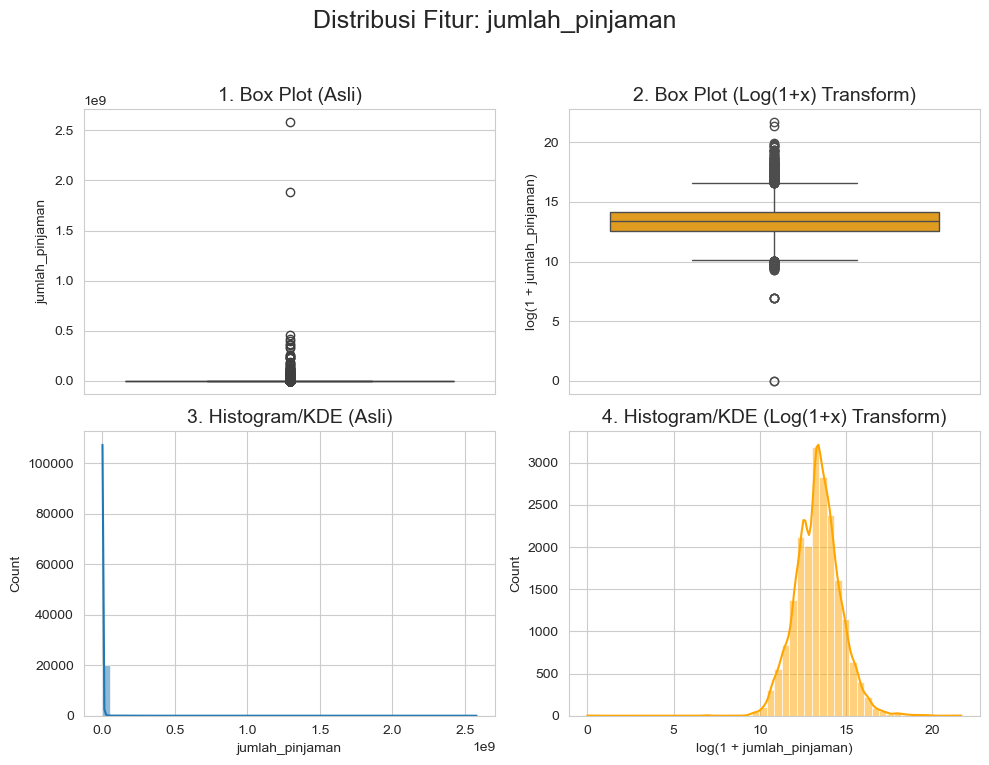

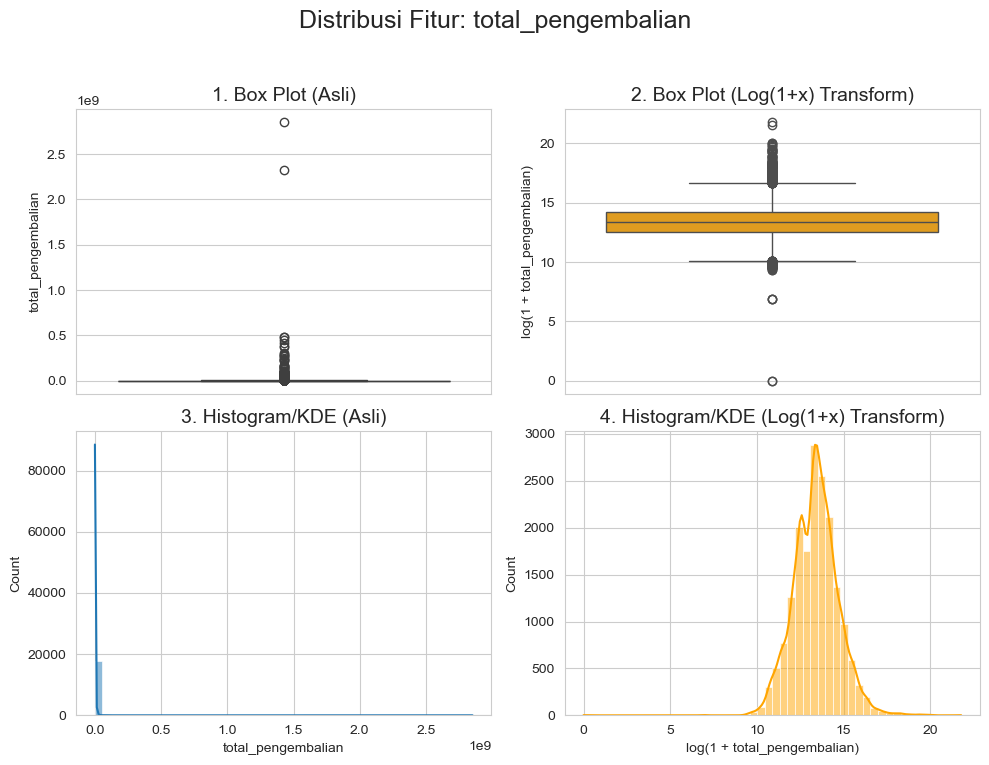

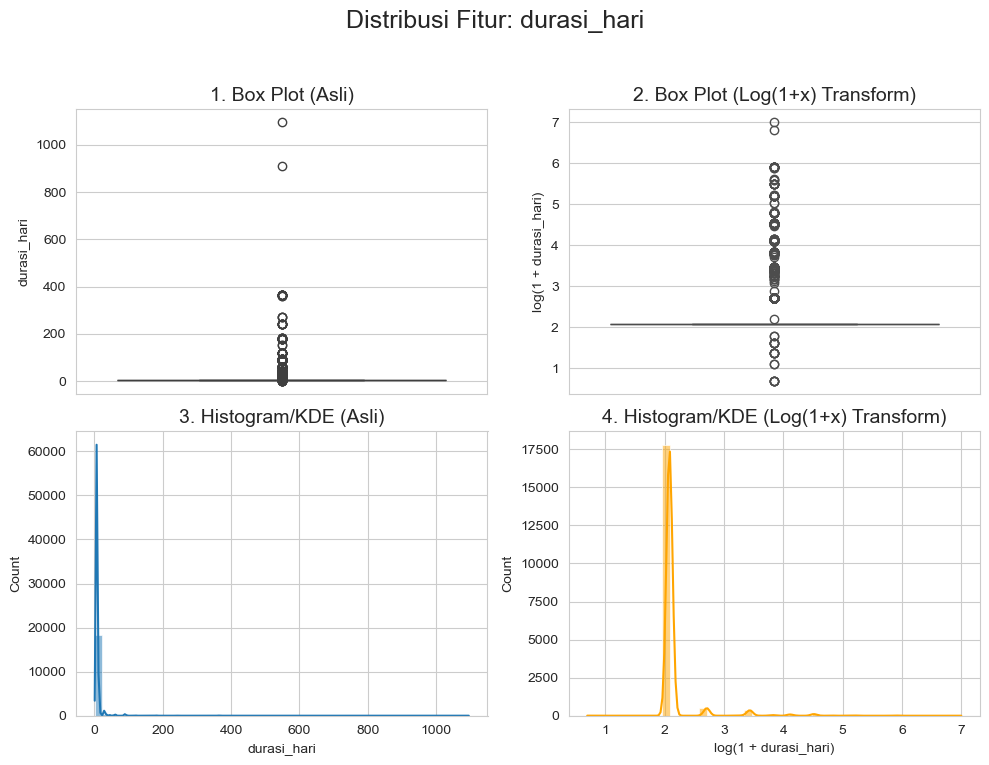

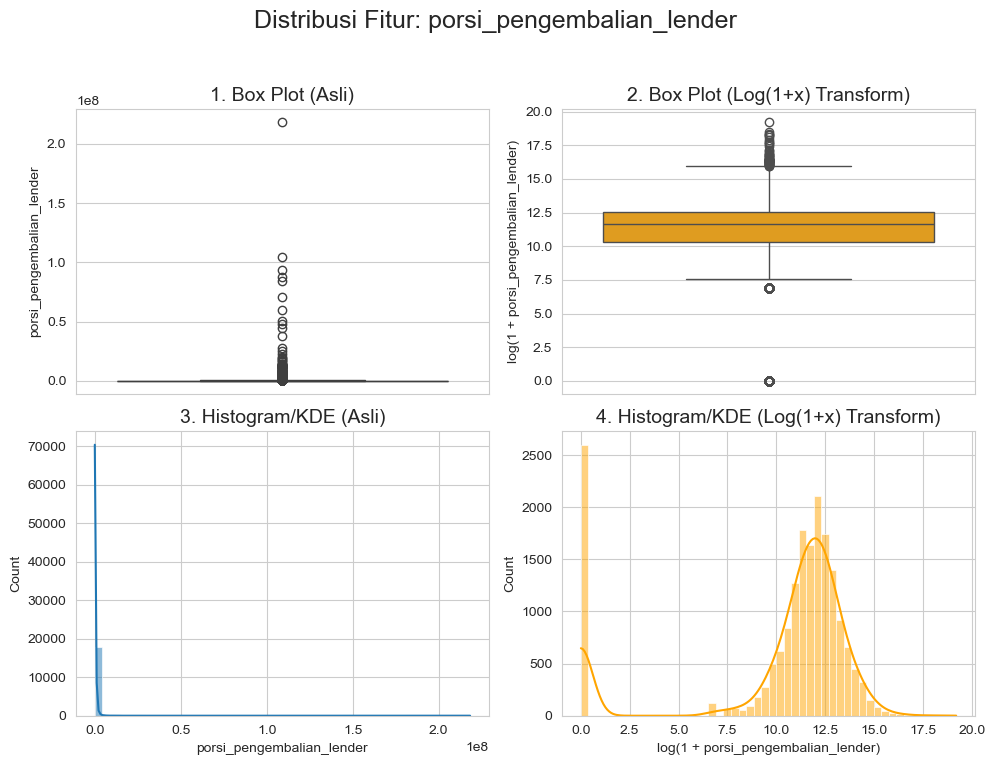

In [ ]:
visualize_numerical_distribution(df_train, numerical)

Insight:
- Kondisi distribusi data setelah dilakukan transformasi logaritmik terlihat lebih normal dan mengurangi dampak outlier, hal ini dapat menjadi bahan pertimbangan untuk scale numerical features dengan transformasi logaritmik pada tahap preprocessing dan feature engineering.

In [ ]:
def visualize_categorical_distribution(fig_x, fig_y, x_label, x_label_rotation, title, column, top_x, df):
    # set size
    plt.figure(figsize=(fig_x, fig_y))
    # count total rows
    total = float(len(df))
    # create countplot chart
    ax = sns.countplot(x=column, data=df, order=df[column].value_counts().iloc[:top_x].index)

    # loop for all bars (patches)
    for p in ax.patches:
        # percentage text
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        # annotation coordinates
        x = p.get_x() + p.get_width() / 2 - 0.05
        y = p.get_y() + p.get_height()
        # write annotation
        ax.annotate(percentage, (x, y), xytext=(x + 0.05, y + 20), ha='center', weight='bold', size=11)
    # formatting
    plt.xticks(rotation=x_label_rotation, weight='bold', size=10)
    plt.yticks(weight='bold', size=10)
    plt.xlabel(x_label, weight='bold', size=12)
    plt.ylabel('count', weight='bold', size=12)
    plt.title(title, weight='bold', size=15)
    plt.show()

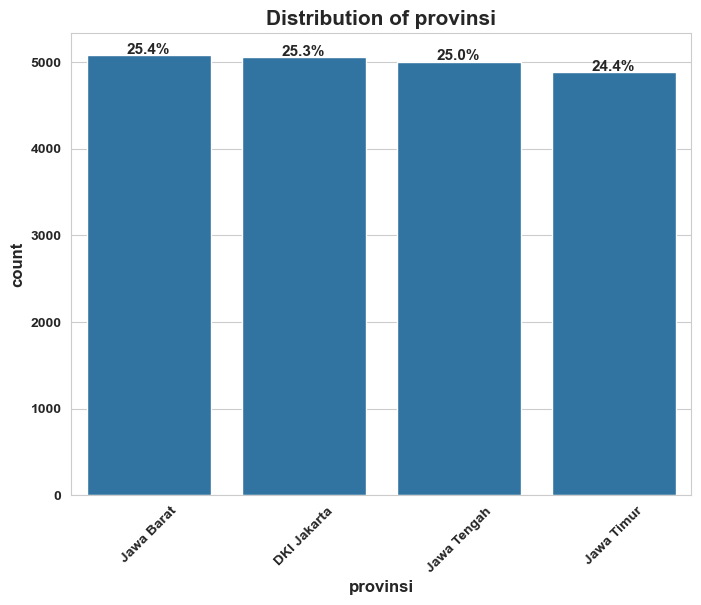

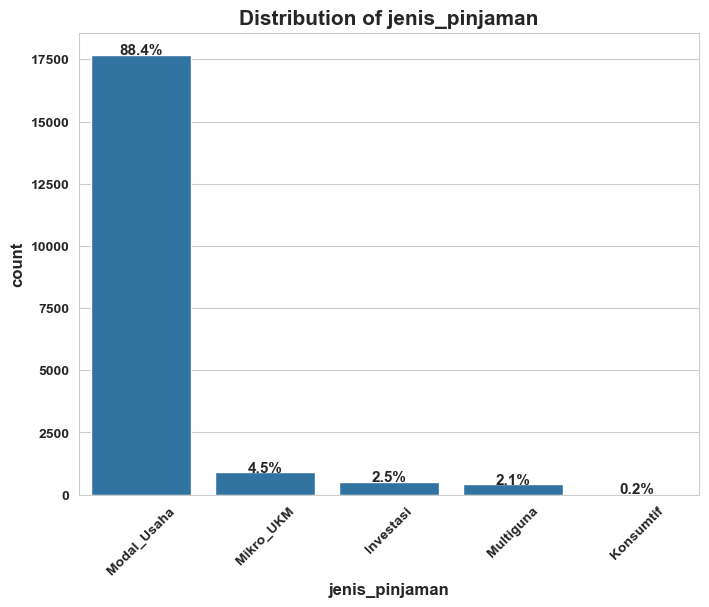

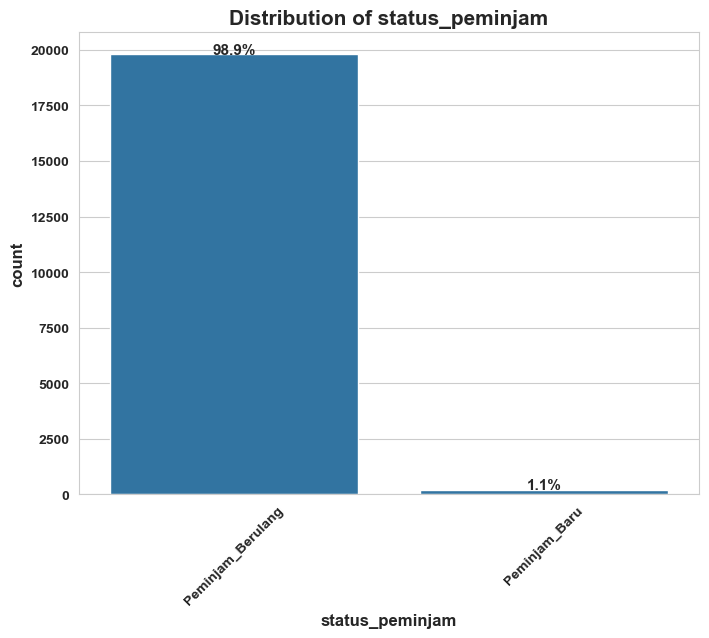

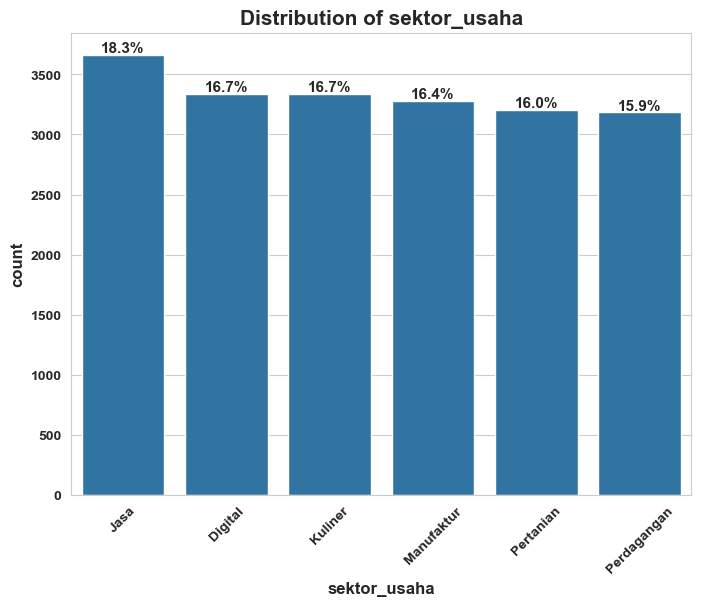

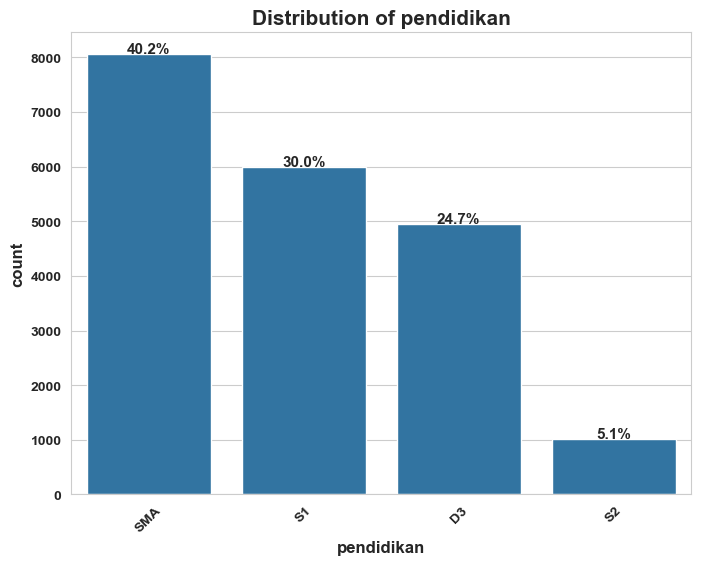

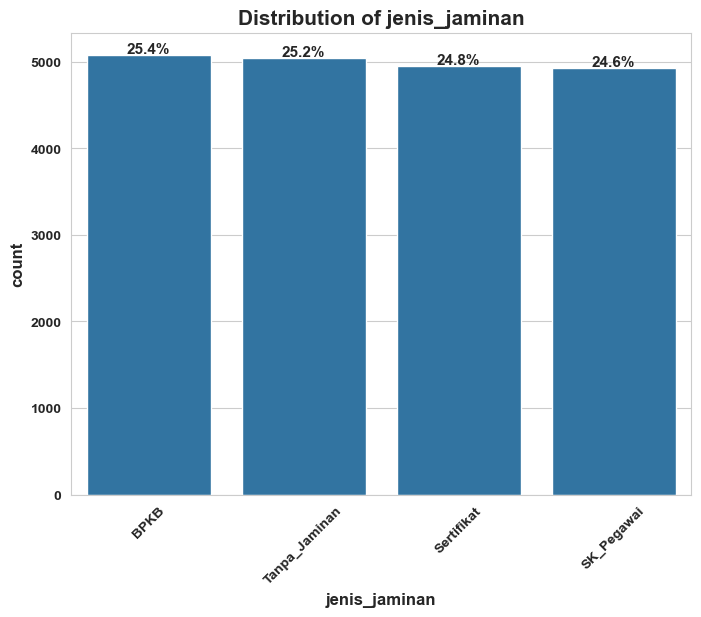

In [ ]:
for col in categorical:
    visualize_categorical_distribution(8, 6, col, 45, f"Distribution of {col}", col, 10, df_train)

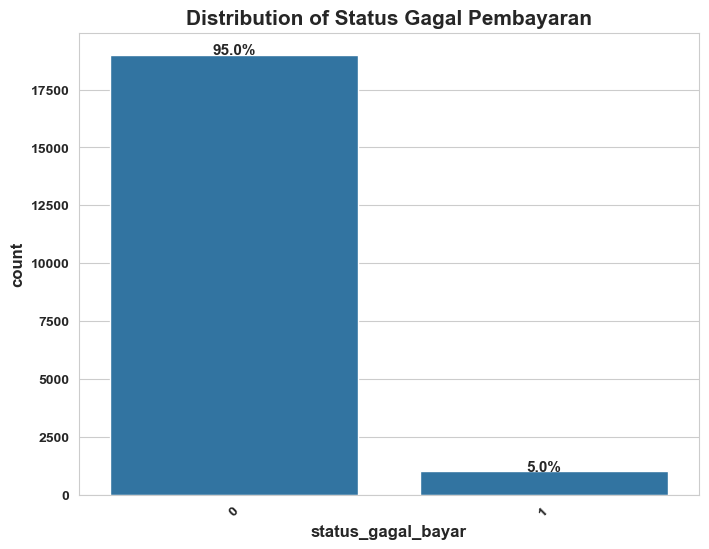

In [ ]:
# target variable distribution
visualize_categorical_distribution(8, 6, "status_gagal_bayar", 45, "Distribution of Status Gagal Pembayaran", "status_gagal_bayar", 10, df_train)

Insight:
- Status gagal bayar sebagai variabel target di sini memiliki ketidakseimbangan kelas yang cukup parah, hal ini butuh ditangani dengan pendekatan khusus agar model nantinya tidak bias serta kinerja prediksi pada tiap kelas bisa lebih baik lagi.

### 2.3 Bivariate Analysis

#### 2.3.1 Bivariate Data Visualization

In [ ]:
def visualize_numerical_distribution_by_target(df, numerical_features, target_col):
    sns.set_style("whitegrid")
    for feature in numerical_features:
        data = df[[feature, target_col]].dropna()
        data = data[data[feature] >= 0]
        # log transform
        data["log_feature"] = np.log1p(data[feature])
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        fig.suptitle(f'Distribusi Fitur Berdasarkan Target: {feature}', fontsize=18)
        # 1. Boxplot asli dengan hue
        sns.boxplot(data=data, x=target_col, y=feature, ax=axes[0, 0])
        axes[0, 0].set_title("1. Box Plot (Asli) per Target", fontsize=14)
        # 2. Boxplot log-transform dengan hue
        sns.boxplot(data=data, x=target_col, y="log_feature", ax=axes[0, 1])
        axes[0, 1].set_title("2. Box Plot (Log(1+x)) per Target", fontsize=14)
        # 3. Histogram + KDE overlay per target
        sns.histplot(data=data, x=feature, hue=target_col, kde=True, bins=50, ax=axes[1, 0])
        axes[1, 0].set_title("3. Histogram/KDE (Asli) per Target", fontsize=14)
        # 4. KDE overlay pakai log-transform (lebih bersih)
        sns.kdeplot(data=data, x="log_feature", hue=target_col, ax=axes[1, 1], fill=True, alpha=0.3)
        axes[1, 1].set_title("4. KDE (Log(1+x)) per Target", fontsize=14)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# categorical vs target
def countplot_bivariate_target(fig_x, fig_y, x_label, x_label_rotation, title, column, top_x, df):
    plt.figure(figsize=(fig_x, fig_y))
    total = float(len(df))
    ax = sns.countplot(x=column, hue='status_gagal_bayar', data=df, order=df[column].value_counts().iloc[:top_x].index)
    # loop for all bars (patches)
    for p in ax.patches:
        height = p.get_height()
        # skip bar if height 0 
        if height == 0:
            continue
        percentage = f"{100 * height / total:.1f}%"
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + height
        ax.annotate(percentage, (x, y), ha='center', va='bottom',weight='bold',size=11)
    # formatting
    plt.xticks(rotation=x_label_rotation, weight='bold', size=10)
    plt.yticks(weight='bold', size=10)
    plt.xlabel(x_label, weight='bold', size=12)
    plt.ylabel('count', weight='bold', size=12)
    plt.title(title, weight='bold', size=15)
    plt.show()

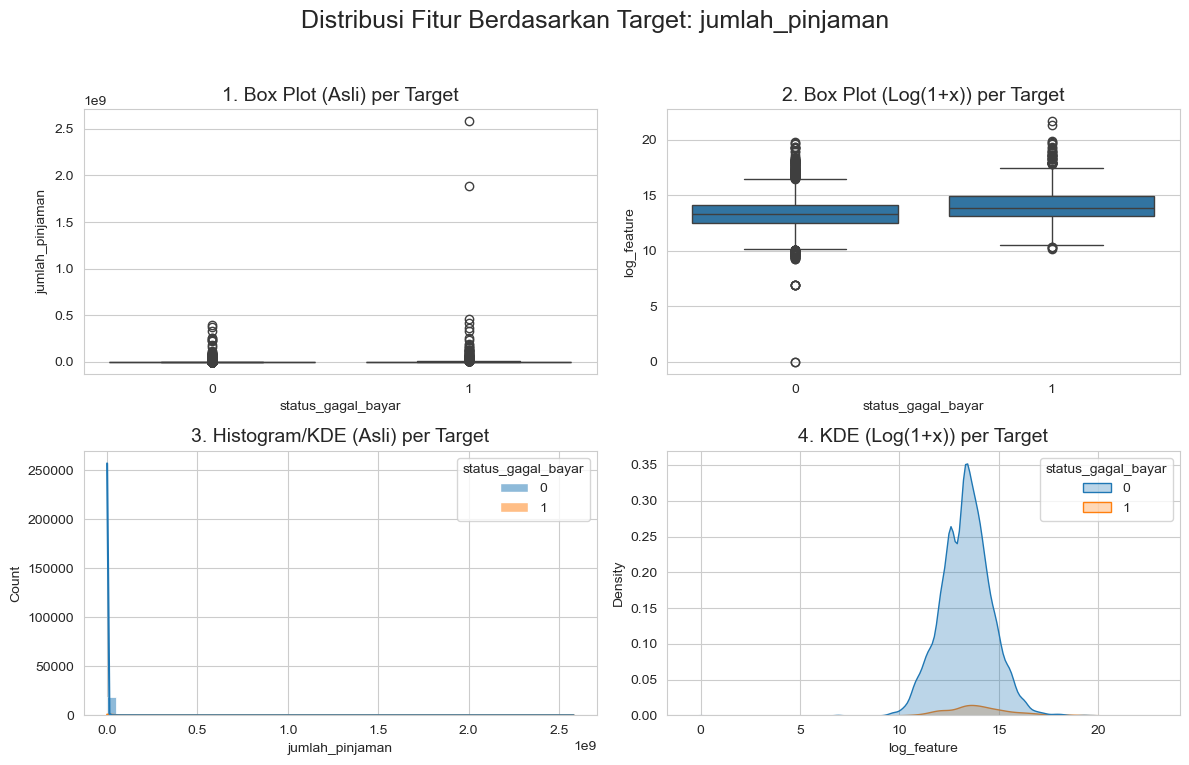

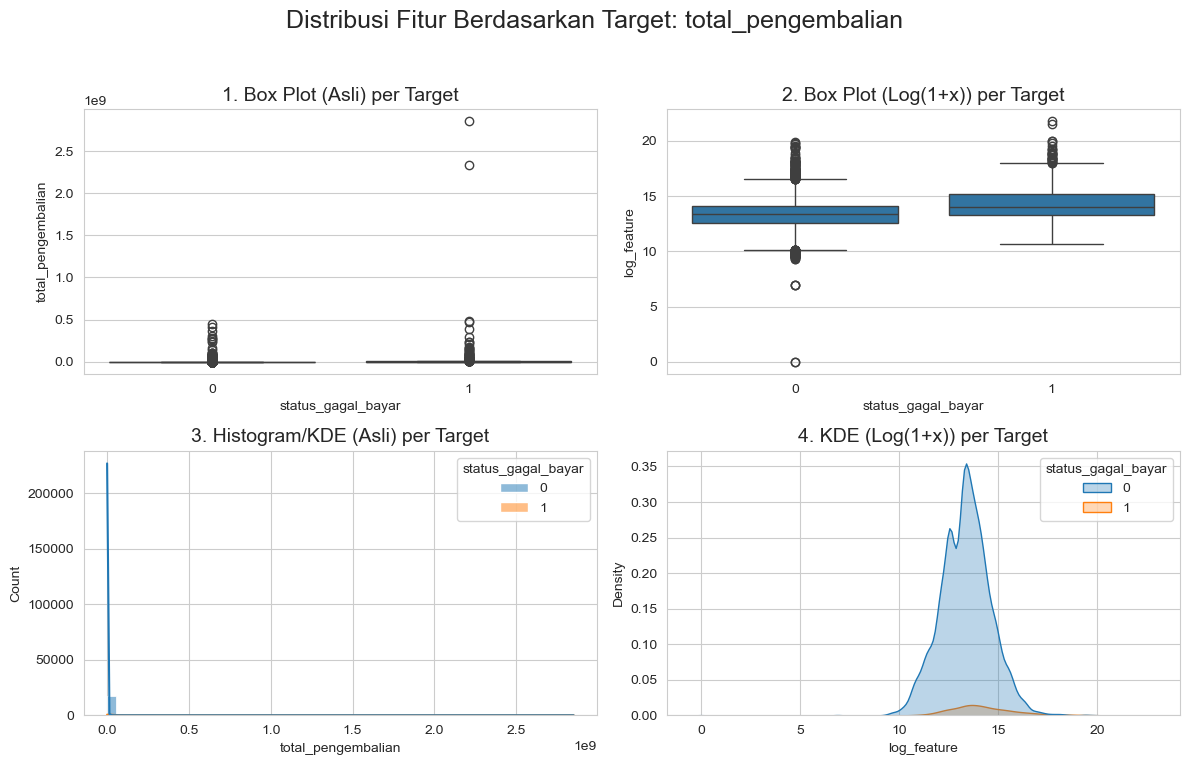

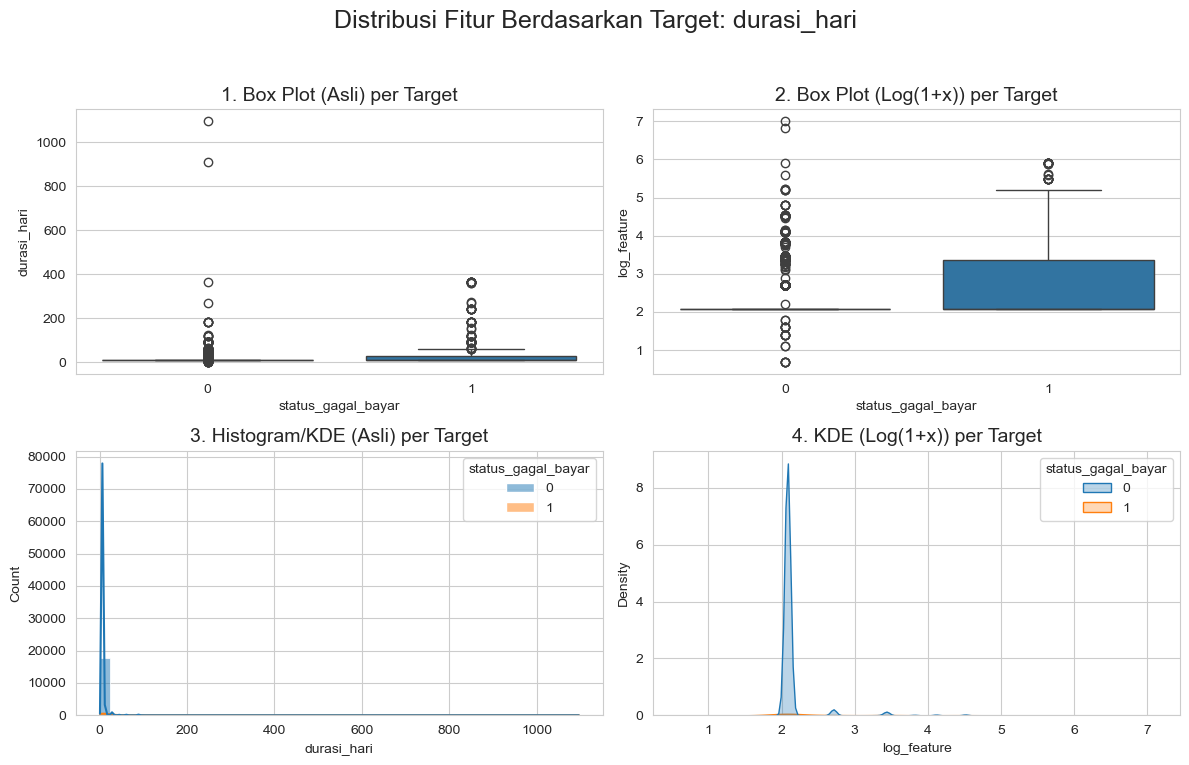

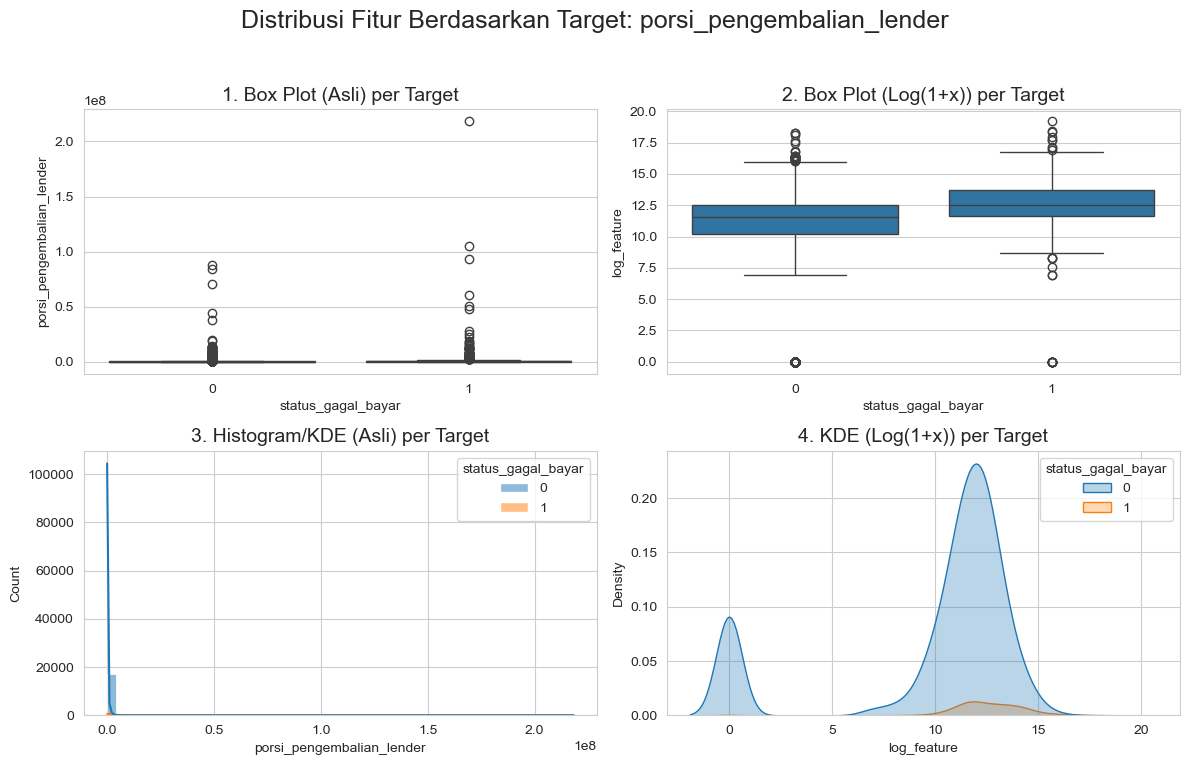

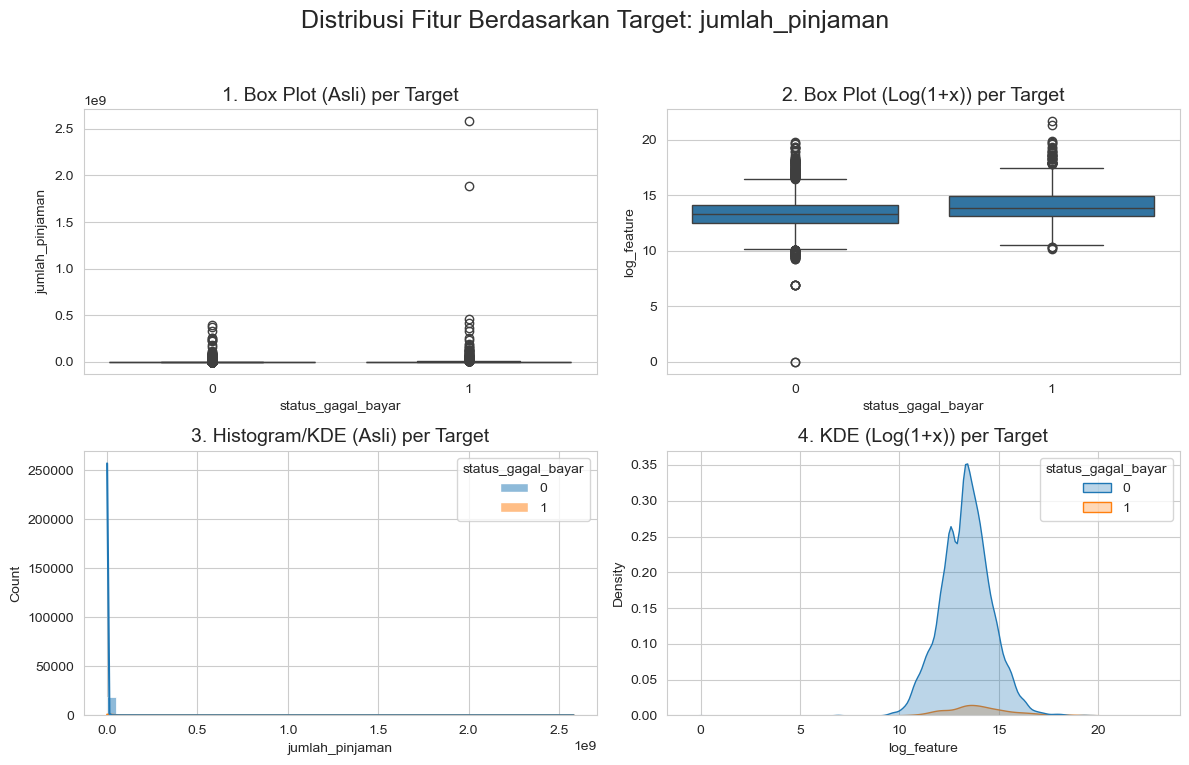

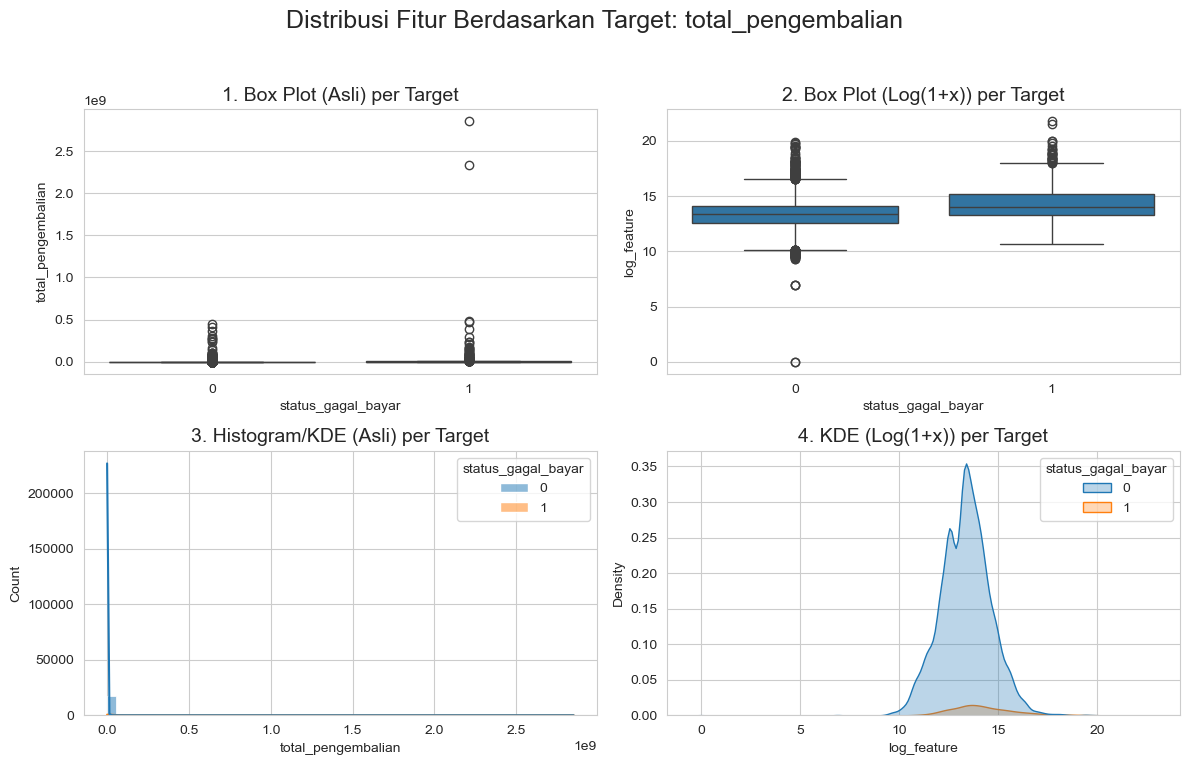

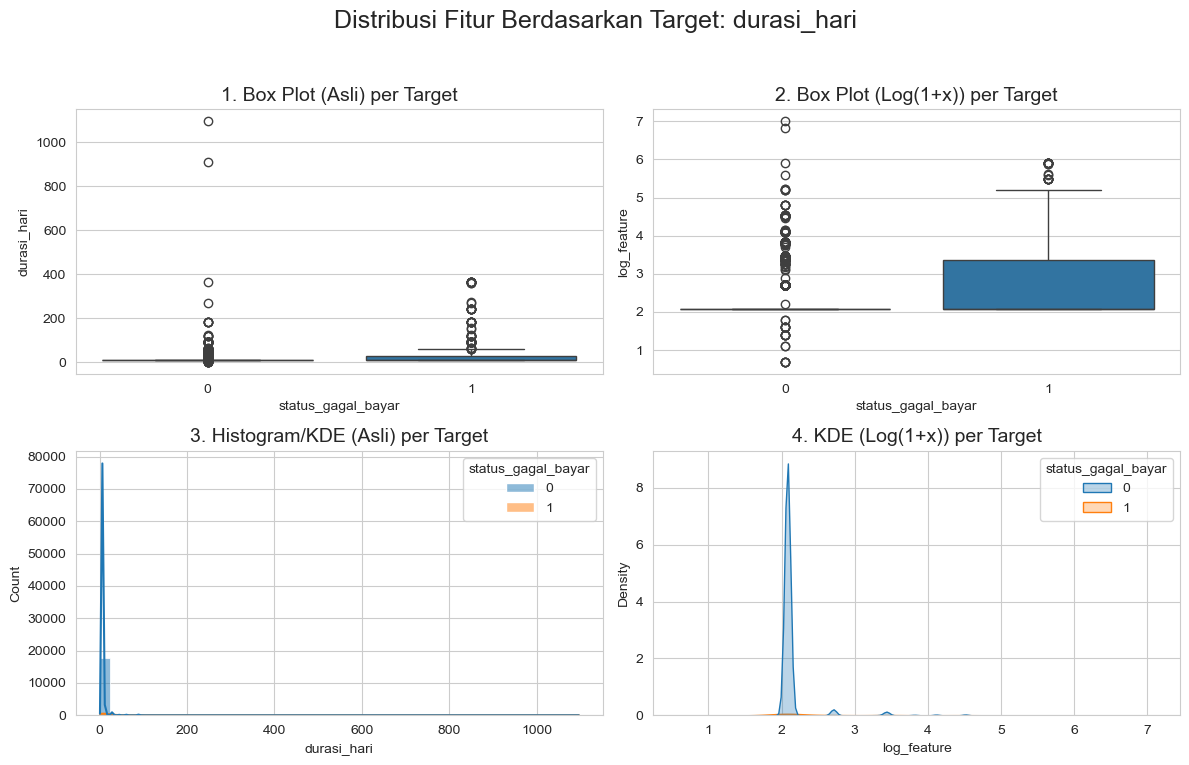

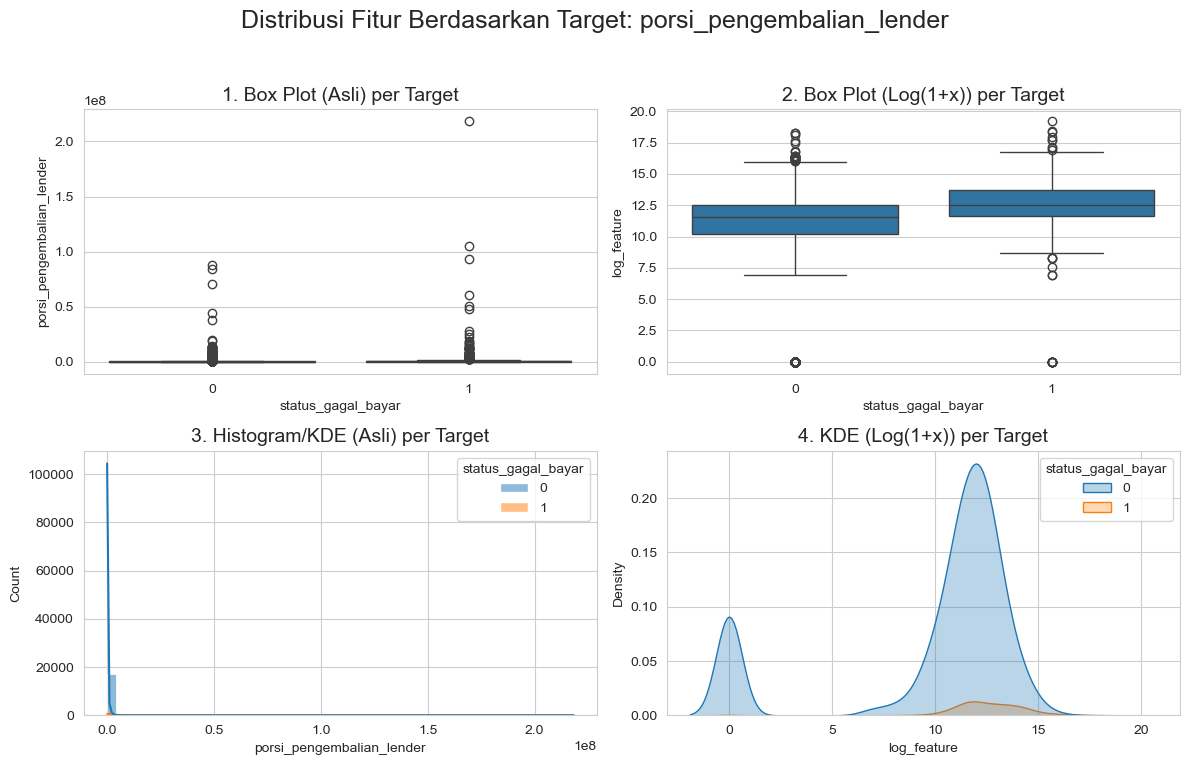

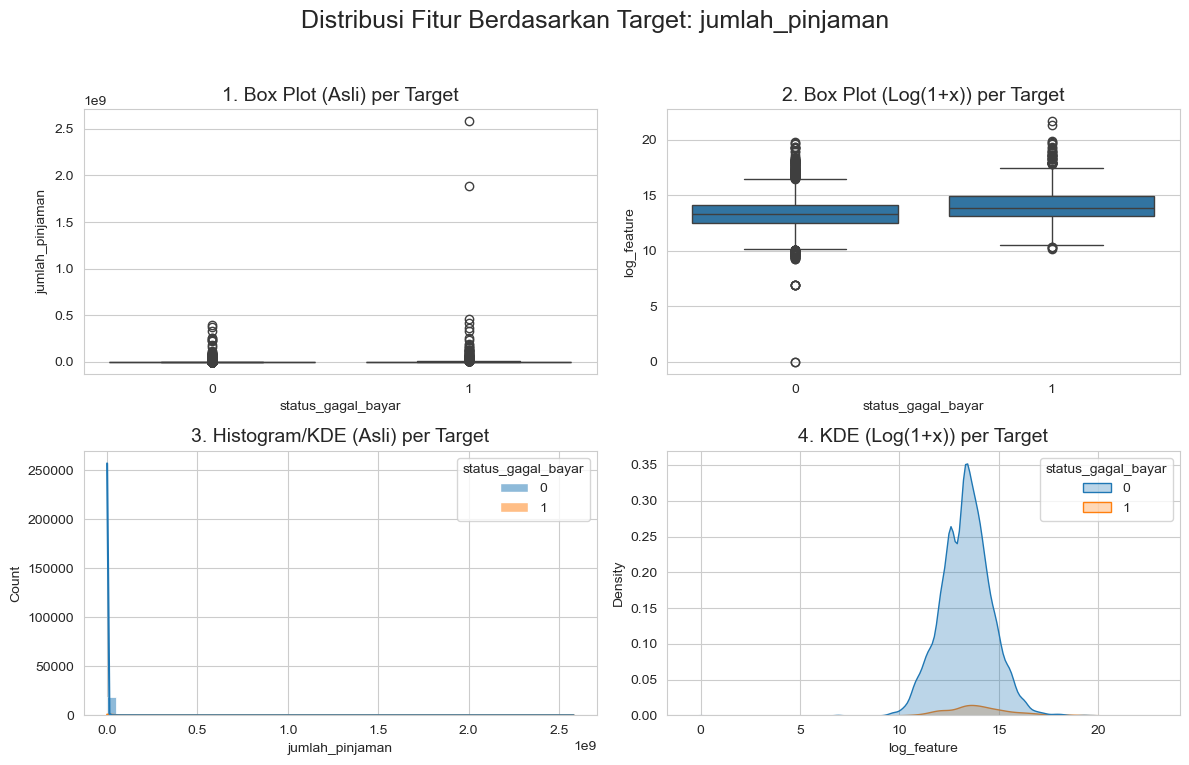

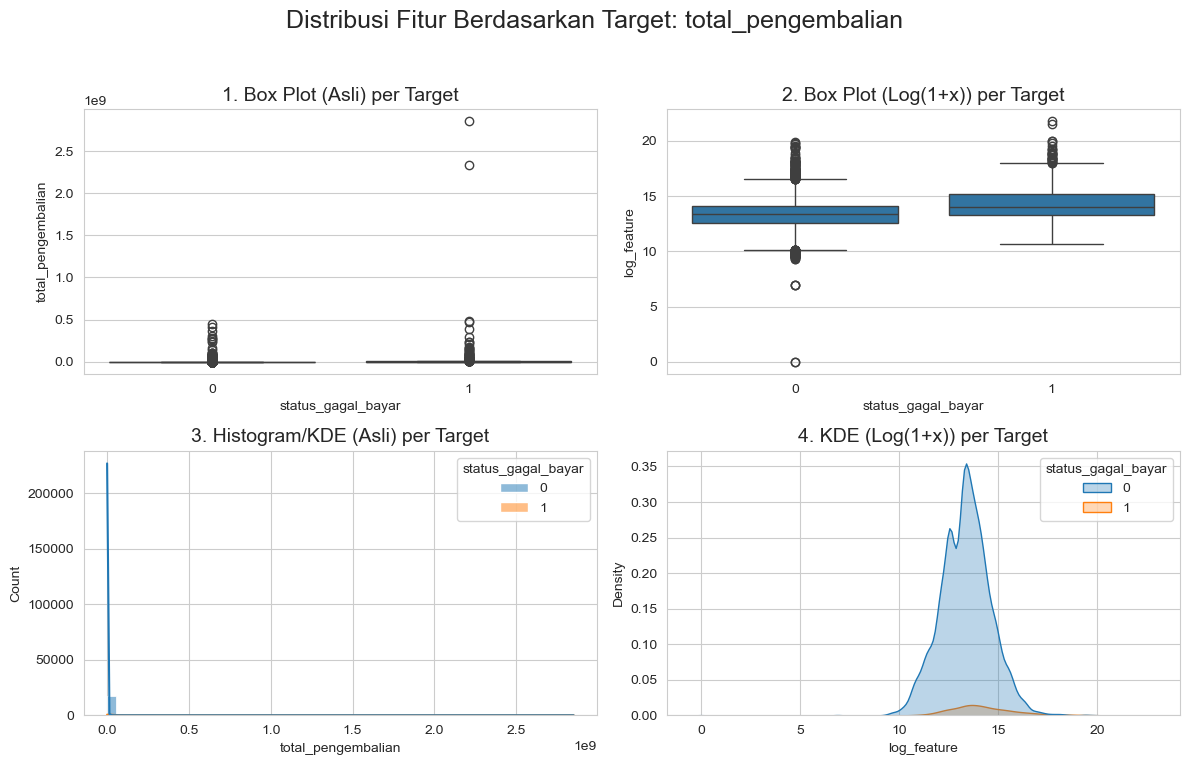

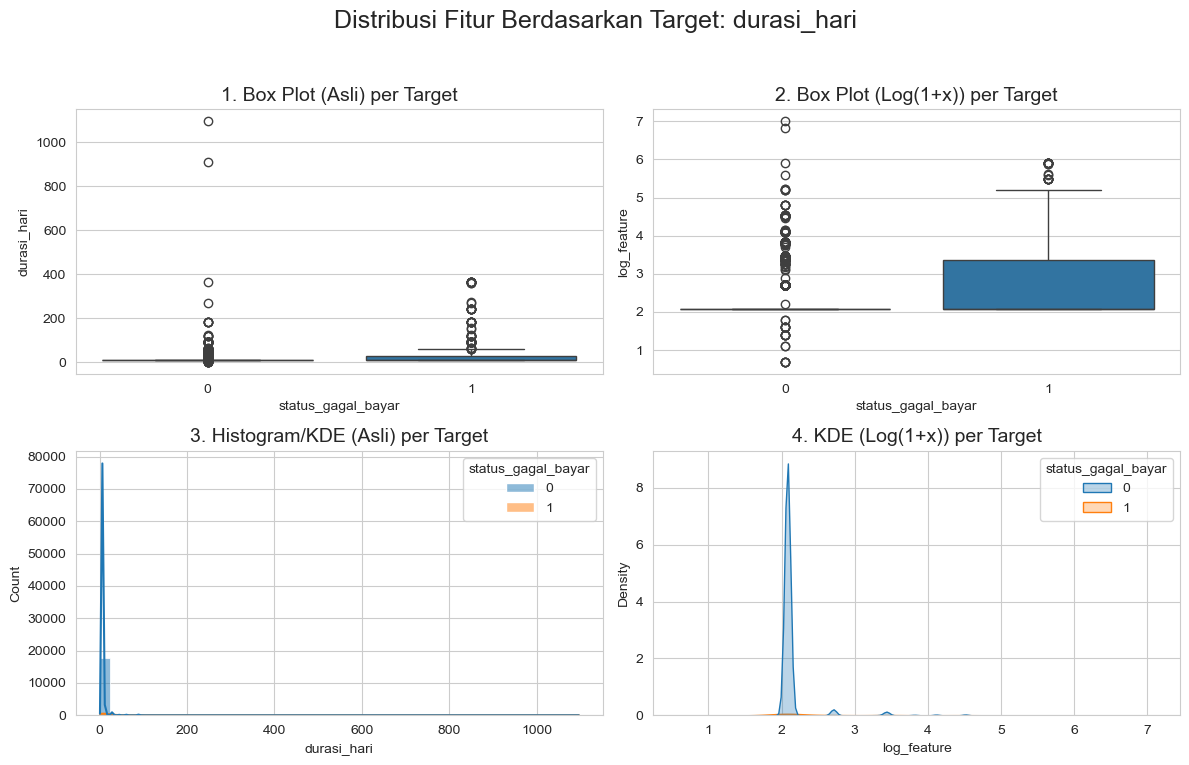

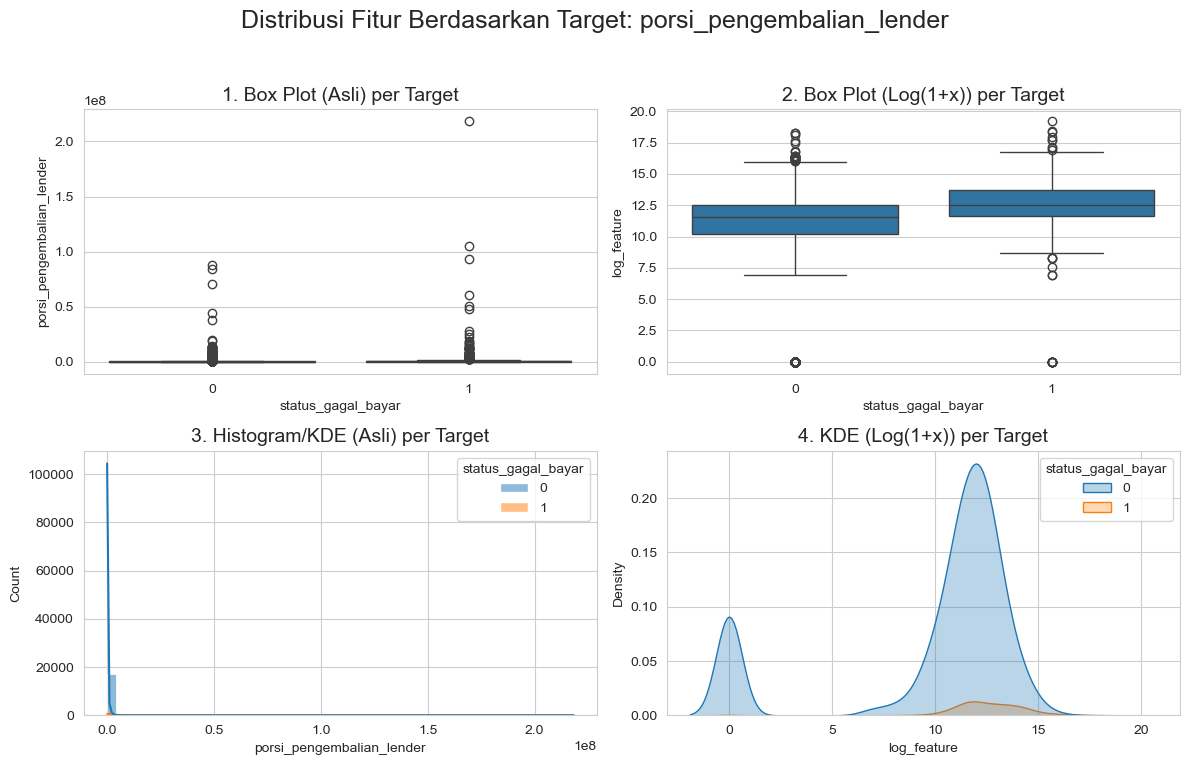

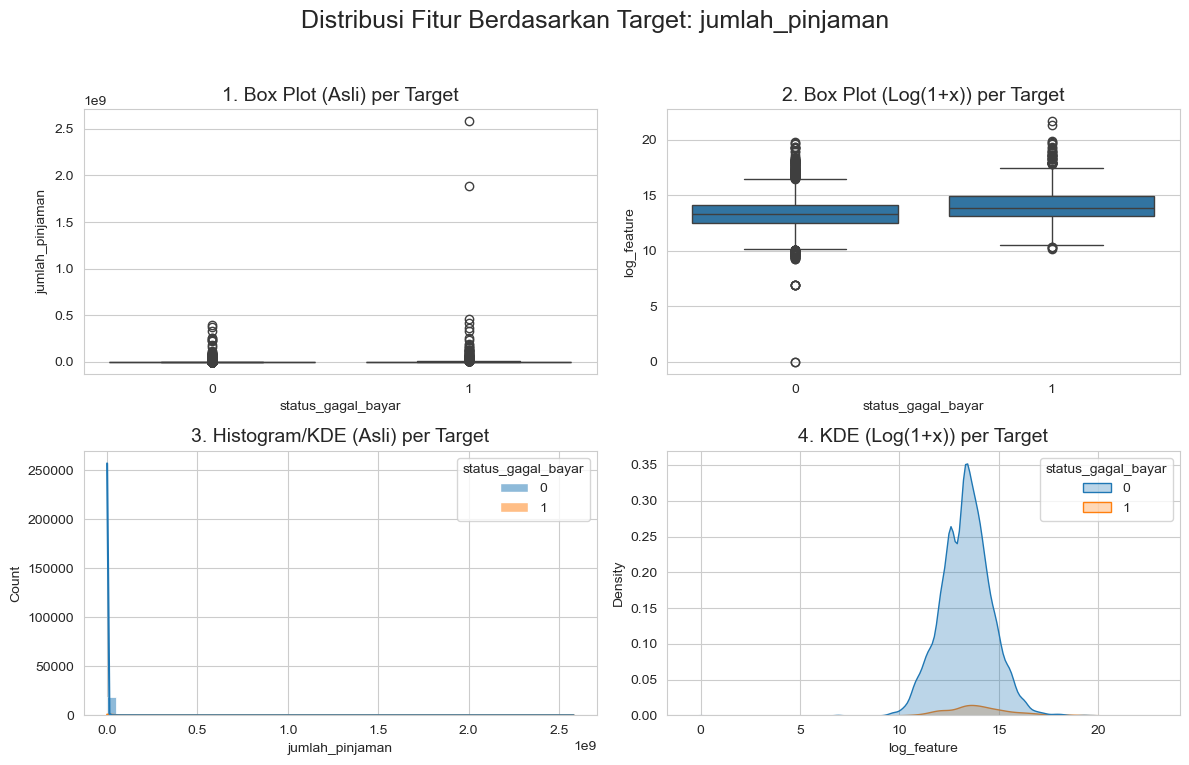

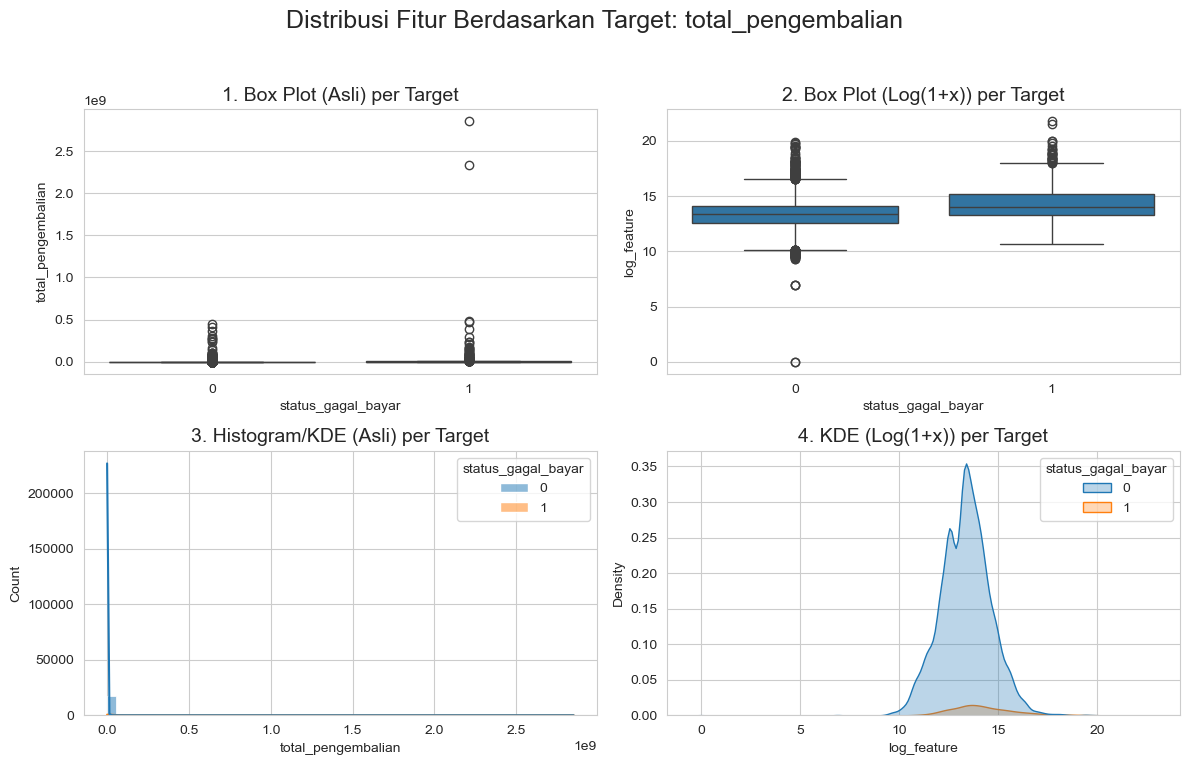

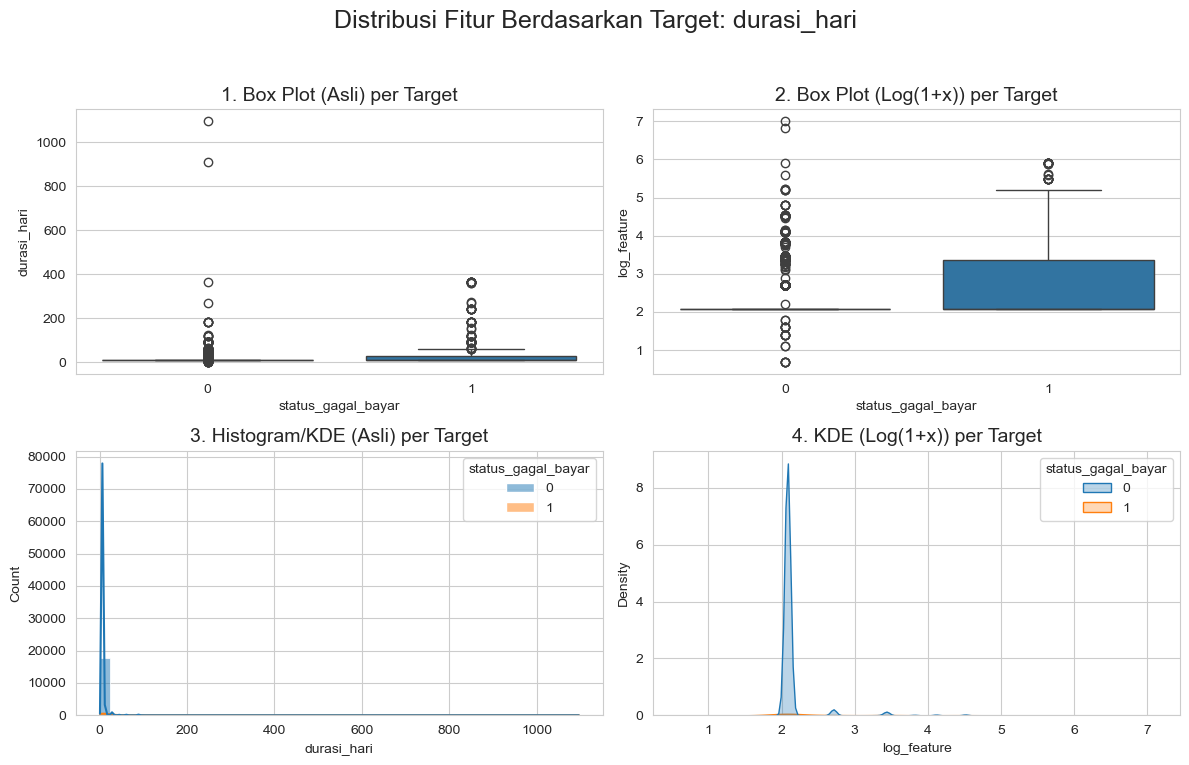

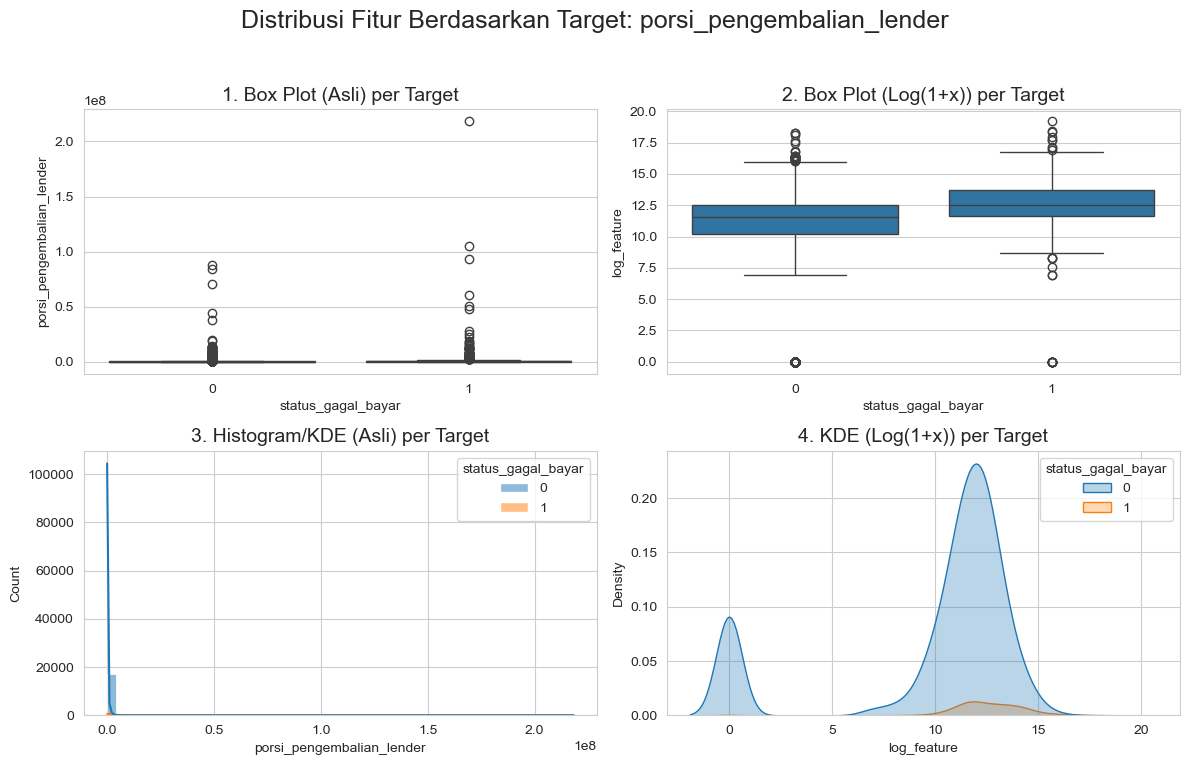

In [ ]:
for col in numerical:
    visualize_numerical_distribution_by_target(df_train, numerical, 'status_gagal_bayar')

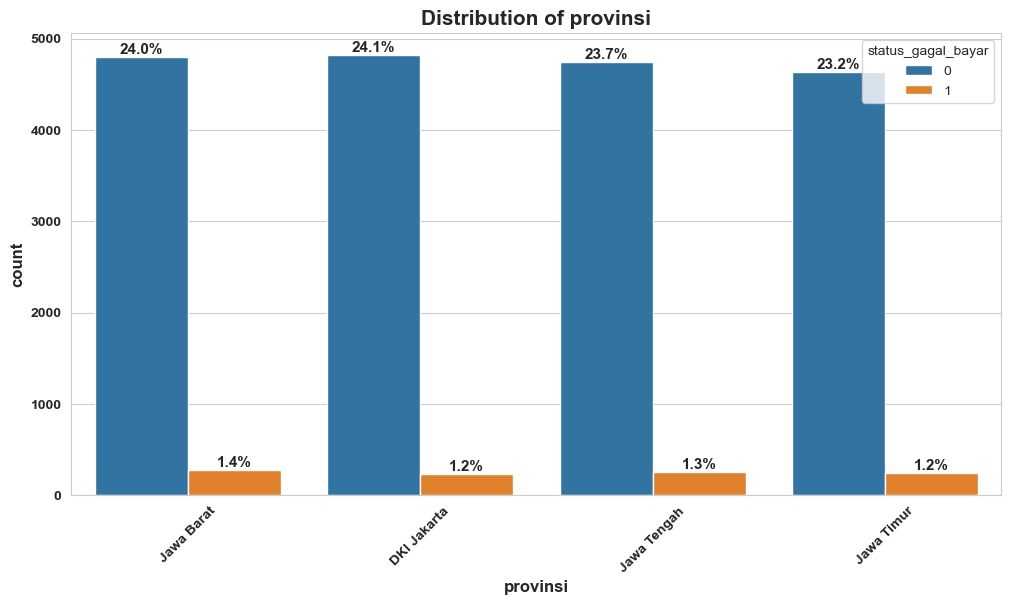

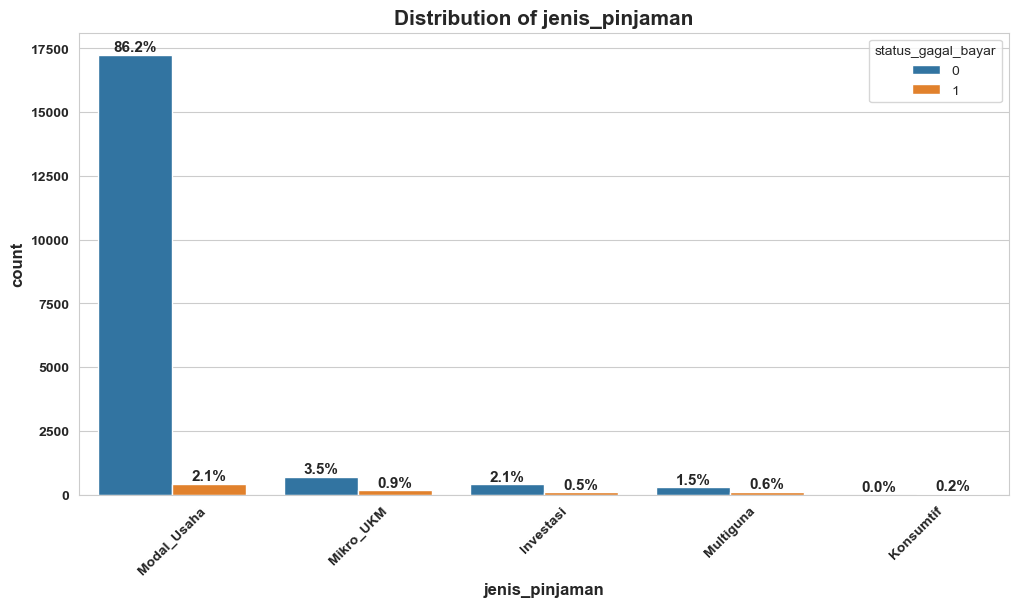

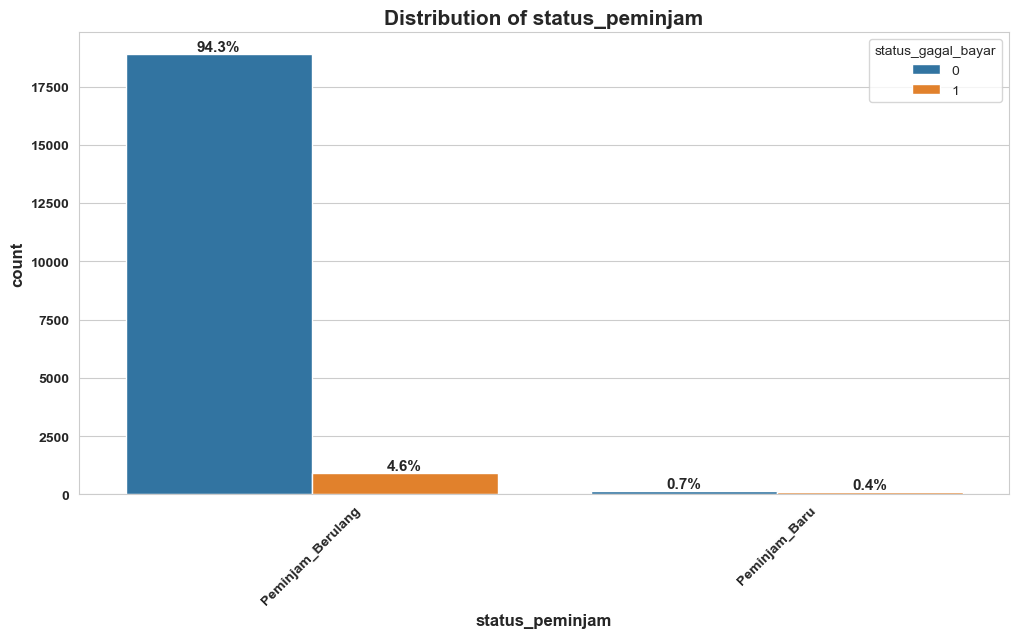

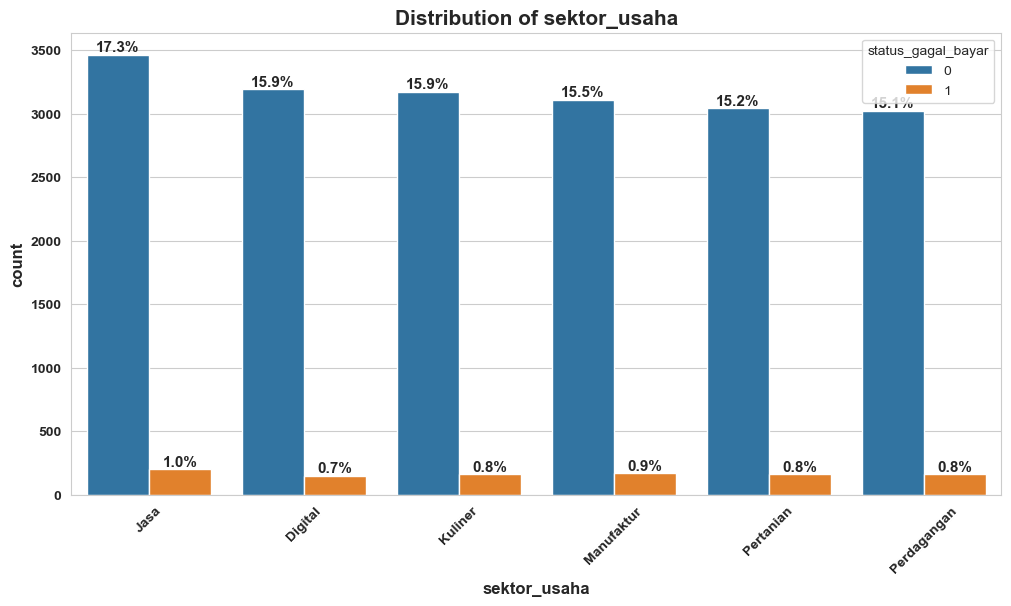

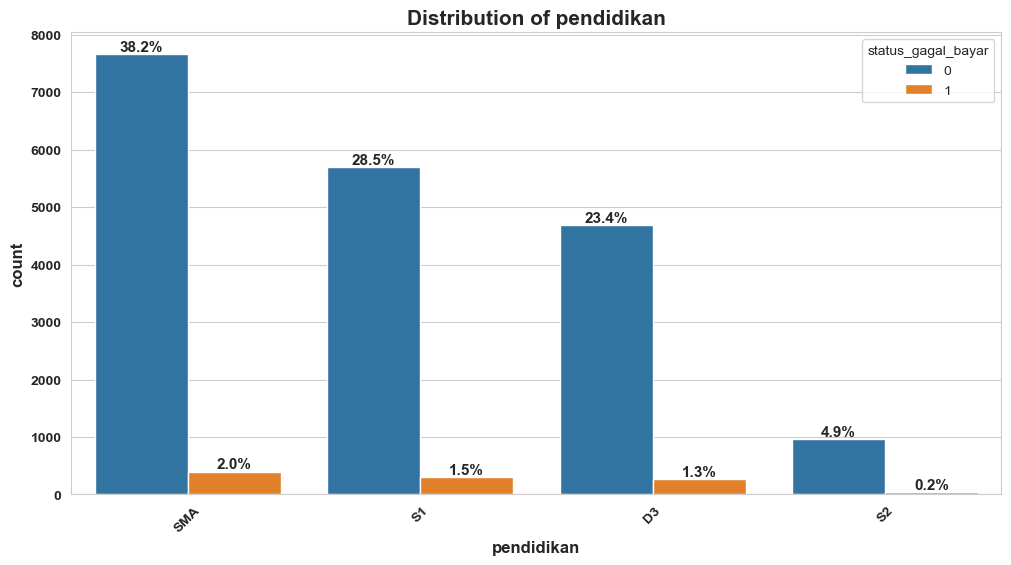

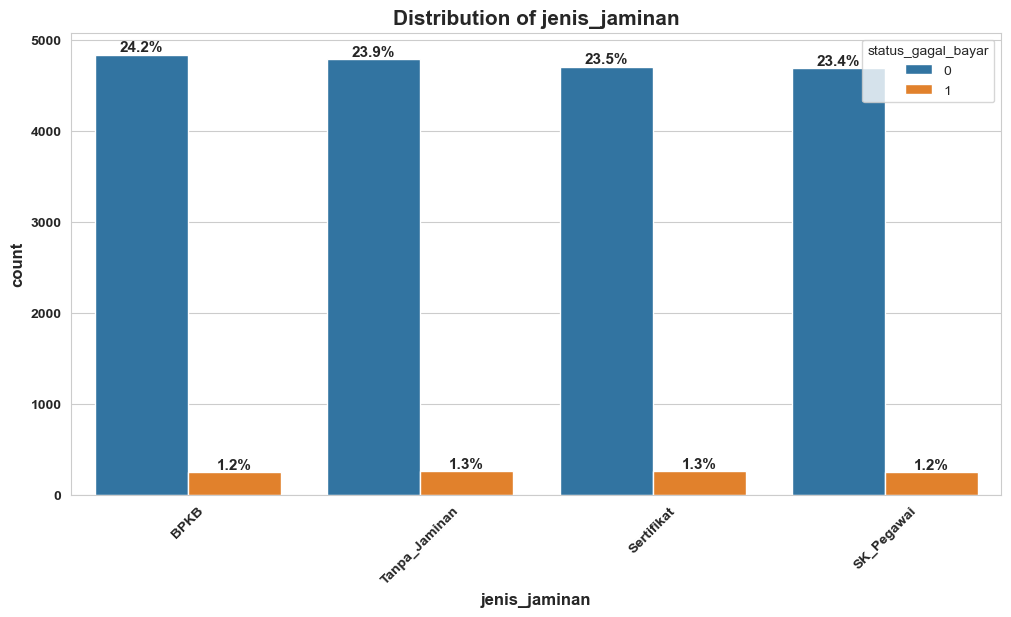

In [ ]:
for col in categorical:
    countplot_bivariate_target(12, 6, col, 45, f"Distribution of {col}", col, 10, df_train)

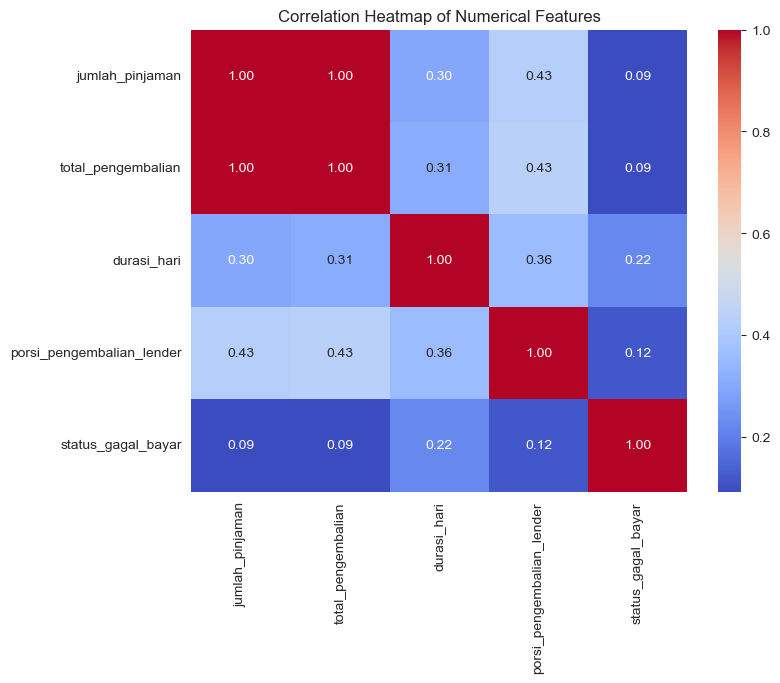

In [ ]:
# visualize heatmap
def visualize_heatmap(df, numerical_features, target, corr_method):
    concate_list = numerical_features + target
    df_numerical = df[concate_list]
    corr_matrix = df_numerical.corr(method=corr_method)
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", cbar=True)
    plt.title("Correlation Heatmap of Numerical Features")
    plt.show()

# usage
visualize_heatmap(df_train, numerical, categorical_binary_target, 'pearson')

### 2.4 Check for Duplicate Instances, Missing Values, and Outliers

In [ ]:
# check for duplicate instance
print(df_train[df_train.duplicated()].shape)

(0, 13)


Inference: 
- Tidak terdapat baris duplikat.

In [ ]:
# missing values identifier
def missing_values_info(df, number_of_features, isDisplayed):
    missing_values = df.isnull().sum().sort_values(ascending = False)
    missing_percentage = (missing_values/len(df)) * 100
    missing_features = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
    if isDisplayed:
        print(missing_features.head(number_of_features))
    else:
        return missing_features

def outliers_info_IQR(df, numerical_features, show_index=False):
    summary_list = []
    outlier_indices = {}
    for col in numerical_features:
        series = df[col].dropna()
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        summary_list.append({
            "Feature": col,
            "Q1": round(Q1, 2),
            "Q3": round(Q3, 2),
            "IQR": round(IQR, 2),
            "Lower Bound": round(lower_bound, 2),
            "Upper Bound": round(upper_bound, 2),
            "Total Outliers": len(outliers),
            "Percent Outliers (%)": round(len(outliers) / len(df) * 100, 2),
        })
        if show_index:
            outlier_indices[col] = outliers.tolist()
    summary_df = pd.DataFrame(summary_list)
    # Ensure nicer display
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 200)
    pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
    if show_index:
        return summary_df, outlier_indices
    else:
        return summary_df

In [ ]:
missing_values_info(df_train, 13, True)

                           Missing Values  Percentage
total_pengembalian                   2065   10.318809
porsi_pengembalian_lender            1960    9.794124
durasi_hari                           800    3.997601
jenis_pinjaman                        469    2.343594
id_transaksi                            0    0.000000
tanggal_pencairan                       0    0.000000
provinsi                                0    0.000000
status_peminjam                         0    0.000000
jumlah_pinjaman                         0    0.000000
sektor_usaha                            0    0.000000
pendidikan                              0    0.000000
jenis_jaminan                           0    0.000000
status_gagal_bayar                      0    0.000000


In [ ]:
missing_values_info(df_test, 13, True)

                           Missing Values  Percentage
durasi_hari                           150    2.998201
jenis_pinjaman                        123    2.458525
total_pengembalian                     57    1.139316
porsi_pengembalian_lender              46    0.919448
id_transaksi                            0    0.000000
tanggal_pencairan                       0    0.000000
provinsi                                0    0.000000
status_peminjam                         0    0.000000
jumlah_pinjaman                         0    0.000000
sektor_usaha                            0    0.000000
pendidikan                              0    0.000000
jenis_jaminan                           0    0.000000


In [ ]:
outliers_info_IQR(df_train, numerical, False)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Total Outliers,Percent Outliers (%)
0,jumlah_pinjaman,"275,000.00","1,384,000.00","1,109,000.00","-1,388,500.00","3,047,500.00",2051,10.25
1,total_pengembalian,"280,000.00","1,429,000.00","1,149,000.00","-1,443,500.00","3,152,500.00",1856,9.27
2,durasi_hari,7.00,7.00,0.00,7.00,7.00,1417,7.08
3,porsi_pengembalian_lender,"30,000.00","287,000.00","257,000.00","-355,500.00","672,500.00",1814,9.06


## 3. Preprocessing and Feature Engineering

In [ ]:
# mengecek kecenderungan nilai tengah dari durasi hari groupby jenis_pinjaman
median_values = df_train.groupby("jenis_pinjaman")["durasi_hari"].median()
mode_values = df_train.groupby("jenis_pinjaman")["durasi_hari"].agg(lambda x: x.mode().iloc[0])
mean_values = df_train.groupby("jenis_pinjaman")["durasi_hari"].mean()
summary = pd.DataFrame({"Mean durasi_hari": mean_values, "Median durasi_hari": median_values, "Mode durasi_hari": mode_values})
print(summary)

                Mean durasi_hari  Median durasi_hari  Mode durasi_hari
jenis_pinjaman                                                        
Investasi                  13.74               14.00             14.00
Konsumtif                 197.97              210.00            365.00
Mikro_UKM                   6.92                7.00              7.00
Modal_Usaha                 6.92                7.00              7.00
Multiguna                  56.24               31.00             30.00


In [ ]:
# menangani [durasi_hari < 0]
for df in [df_train, df_test]:
    # membuat fitur binary sebagai flag
    df['is_durasi_hari_negative'] = (df['durasi_hari'] < 0).astype(int)
    # konversi nilai negatif pada durasi_hari menjadi missing
    df.loc[df['durasi_hari'] < 0, 'durasi_hari'] = np.nan

# menangani missing pada feature durasi_hari menggunakan median durasi_hari per jenis_pinjaman
df_train['durasi_hari'] = df_train['durasi_hari'].fillna(df_train.groupby('jenis_pinjaman')['durasi_hari'].transform('median'))
# kalkuklasi median durasi_hari per jenis_pinjaman
median_durasi_hari_per_jenis_pinjaman = df_train.groupby('jenis_pinjaman')['durasi_hari'].median()
df_test['durasi_hari'] = df_test['durasi_hari'].fillna(df_test['jenis_pinjaman'].map(median_durasi_hari_per_jenis_pinjaman))
# NOTE: cara di atas mungkin membuat durasi_hari masih tetap akan ada yang missing jika dan hanya jika jenis_pinjaman yg bersesuaian juga missing

# menangani missing pada feature jenis_pinjaman
# urut berdasarkan tanggal_pencairan
df_train = df_train.sort_values("tanggal_pencairan").reset_index(drop=True)
df_test  = df_test.sort_values("tanggal_pencairan").reset_index(drop=True)
# lakukan ffill() bfill() dengan pendekatan groupby durasi_hari
df_train['jenis_pinjaman'] = (df_train.groupby('durasi_hari')['jenis_pinjaman'].transform(lambda x: x.ffill().bfill()))
df_test['jenis_pinjaman'] = (df_test.groupby('durasi_hari')['jenis_pinjaman'].transform(lambda x: x.ffill().bfill()))
# NOTE: mungkin saja yang durasi_hari tidak missing tetapi jenis_pinjaman tetap missing dikarenakan untuk suatu grup dari durasi_hari tersebut jenis_pinjaman nya kosong.

# menangani sisa missing pada feature jenis_pinjaman yang di mana durasi_hari tidak missing
# jika durasi_hari mendekati nilai median durasi_hari per jenis_pinjaman tertentu, maka jenis_pinjaman missing diisi dengan nilai jenis_pinjaman tersebut
# hitung selisih absolut durasi_hari terhadap median tiap jenis pinjaman
median_map = median_durasi_hari_per_jenis_pinjaman.to_dict()
def get_nearest_jenis_pinjaman_type(durasi, median_dict):
    differences = {loan_type: abs(durasi - median_value)for loan_type, median_value in median_dict.items()}
    return min(differences, key=differences.get)
def fill_missing_loan_type_by_nearest_duration(df, median_dict):
    valid_cond = df['jenis_pinjaman'].isna() & df['durasi_hari'].notna()
    df.loc[valid_cond, 'jenis_pinjaman'] = (df.loc[valid_cond, 'durasi_hari'].apply(lambda d: get_nearest_jenis_pinjaman_type(d, median_dict)))
    return df
df_train = fill_missing_loan_type_by_nearest_duration(df_train, median_map)
df_test  = fill_missing_loan_type_by_nearest_duration(df_test,  median_map)

# menangani sisa missing pada feature jenis_pinjaman yang di mana durasi_hari juga missing
# ffill() dan bfill() secara global
df_train["jenis_pinjaman"] = df_train["jenis_pinjaman"].ffill().bfill()
df_test["jenis_pinjaman"] = df_test["jenis_pinjaman"].ffill().bfill()

# urut berdasarkan id_transaksi lagi
df_train = df_train.sort_values("id_transaksi").reset_index(drop=True)
df_test  = df_test.sort_values("id_transaksi").reset_index(drop=True)

# menangani sisa missing pada feature durasi_hari menggunakan median durasi_hari per jenis_pinjaman
df_train['durasi_hari'] = (df_train['durasi_hari'].fillna(df_train['jenis_pinjaman'].map(median_map)))
df_test['durasi_hari'] = (df_test['durasi_hari'].fillna(df_test['jenis_pinjaman'].map(median_map)))

C:\Users\tutoi\AppData\Local\Temp\ipykernel_7256\177794877.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['jenis_pinjaman'] = (df_train.groupby('durasi_hari')['jenis_pinjaman'].transform(lambda x: x.ffill().bfill()))
C:\Users\tutoi\AppData\Local\Temp\ipykernel_7256\177794877.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['jenis_pinjaman'] = (df_test.groupby('durasi_hari')['jenis_pinjaman'].transform(lambda x: x.ffill().bfill()))


In [ ]:
# proporsi missing values saat ini pada train set
missing_values_info(df_train, 13, True)

                           Missing Values  Percentage
total_pengembalian                   2065       10.32
porsi_pengembalian_lender            1960        9.79
id_transaksi                            0        0.00
tanggal_pencairan                       0        0.00
provinsi                                0        0.00
jenis_pinjaman                          0        0.00
status_peminjam                         0        0.00
jumlah_pinjaman                         0        0.00
durasi_hari                             0        0.00
sektor_usaha                            0        0.00
pendidikan                              0        0.00
jenis_jaminan                           0        0.00
status_gagal_bayar                      0        0.00


In [ ]:
# proporsi missing values saat ini pada test set
missing_values_info(df_test, 13, True)

                           Missing Values  Percentage
total_pengembalian                     57        1.14
porsi_pengembalian_lender              46        0.92
id_transaksi                            0        0.00
tanggal_pencairan                       0        0.00
provinsi                                0        0.00
jenis_pinjaman                          0        0.00
status_peminjam                         0        0.00
jumlah_pinjaman                         0        0.00
durasi_hari                             0        0.00
sektor_usaha                            0        0.00
pendidikan                              0        0.00
jenis_jaminan                           0        0.00
is_durasi_hari_negative                 0        0.00


In [ ]:
# mengangani fitur tanggal_pencairan ... (1)
all_dates = pd.concat([df_train['tanggal_pencairan'], df_test['tanggal_pencairan']]).max()
reference_date = all_dates + pd.Timedelta(days=1) # Tambah 1 hari agar hasil durasi > 0

def extract_time_features(df, date_column='tanggal_pencairan'): 
    # df['durasi_hari_sejak_pencairan'] = (reference_date - df['tanggal_pencairan']).dt.days
    df['durasi_hari_sejak_pencairan'] = (reference_date - df['tanggal_pencairan']).dt.days
    df['tahun'] = df[date_column].dt.year
    df['bulan'] = df[date_column].dt.month
    df['hari_dalam_bulan'] = df[date_column].dt.day
    df['hari_dalam_minggu'] = df[date_column].dt.dayofweek
    df['kuartal'] = df[date_column].dt.quarter
    df['is_weekend'] = df['hari_dalam_minggu'].apply(lambda x: 1 if x >= 5 else 0)
    # Hapus kolom tanggal asli agar tidak redundan
    df = df.drop(columns=[date_column], errors='ignore')
    return df

df_train = extract_time_features(df_train.copy())
df_test = extract_time_features(df_test.copy())

In [ ]:
# menangani fitur tanggal_pencairan ... (2)
def cyclic_transformation(df):
    # Transformasi Bulan (Siklus 12 bulan)
    df['bulan_sin'] = np.sin(2 * np.pi * df['bulan'] / 12)
    df['bulan_cos'] = np.cos(2 * np.pi * df['bulan'] / 12)
    # Transformasi Hari dalam Seminggu (Siklus 7 hari)
    df['hari_bulan_sin'] = np.sin(2 * np.pi * df['hari_dalam_bulan'] / 31)
    df['hari_bulan_cos'] = np.cos(2 * np.pi * df['hari_dalam_bulan'] / 31)
    # Hapus kolom hasil ekstraksi yang sudah ditransformasi agar tidak redundan 
    df = df.drop(columns=['bulan', 'hari_dalam_bulan'], errors='ignore')
    return df

df_train = cyclic_transformation(df_train.copy())
df_test = cyclic_transformation(df_test.copy())

Note:
- Pertimbangkan untuk melakukan OHE terhadap fitur `tahun`, `kuartal`, dan `hari_dalam_minggu` saat melakukan *categorical feature encoding*.

In [ ]:
# feature engineering: menangani keterkaitan tidak logis antar fitur [total_pengembalian < jumlah_pinjaman]
def handle_illogical_total_pengembalian(df):
    # identifikasi baris yang melanggar logika (total_pengembalian < jumlah_pinjaman)
    illogical_condition = (df['total_pengembalian'] < df['jumlah_pinjaman'])
    # buat kolom indikator (1 = Melanggar, 0 = Logis)
    df['is_total_pengembalian_illogical'] = illogical_condition.astype(int)
    # koreksi berbasis aturan domain dengan mengganti nilai total_pengembalian yang dianggap tidak logis
    # penggantian nilai menggunakan nilai minimum logis dari total pengembalian, yakni setara jumlah pinjaman
    df.loc[illogical_condition, 'total_pengembalian'] = df.loc[illogical_condition, 'jumlah_pinjaman']
    return df

df_train = handle_illogical_total_pengembalian(df_train)
df_test = handle_illogical_total_pengembalian(df_test)

In [ ]:
median_global = (df_train['total_pengembalian'] / df_train['jumlah_pinjaman']).median()
median_per_group =  (df_train['total_pengembalian'] / df_train['jumlah_pinjaman']).groupby(df_train['jenis_pinjaman']).median()

print("Median global dari total_pengembalian/jumlah_pinjaman:", median_global)
print("\nMedian per jenis_pinjaman:")
print(median_per_group)

Median global dari total_pengembalian/jumlah_pinjaman: 1.010752688172043

Median per jenis_pinjaman:
jenis_pinjaman
Investasi     1.06
Konsumtif     1.23
Mikro_UKM     1.04
Modal_Usaha   1.01
Multiguna     1.07
dtype: float64


In [ ]:
def ratio_based_imputation(df_train, df_test, target_col, base_col, group_col):
    # set data yang valid untuk perhitungan rasio
    train_valid = df_train[df_train[target_col].notna() & df_train[base_col].notna()]
    # median dari rasio per grup
    median_rasio_per_grup = ((train_valid[target_col] / train_valid[base_col]).groupby(train_valid[group_col]).median())
    # median dari rasio (global)
    median_rasio_global = (train_valid[target_col] / train_valid[base_col]).median()
    # ambil ratio yang sesuai (group → median group, fallback → global)
    rasio_train = df_train[group_col].map(median_rasio_per_grup).fillna(median_rasio_global)
    rasio_test  = df_test[group_col].map(median_rasio_per_grup).fillna(median_rasio_global)
    # baris-baris yang eligible untuk imputasi
    mask_train = df_train[target_col].isna() & df_train[base_col].notna()
    mask_test  = df_test[target_col].isna() & df_test[base_col].notna()
    # imputasi train
    df_train.loc[mask_train, target_col] = (df_train.loc[mask_train, base_col] * 1.010752688172043)#rasio_train[mask_train])
    # imputasi test
    df_test.loc[mask_test, target_col] = (df_test.loc[mask_test, base_col] * 1.010752688172043)#rasio_test[mask_test])
    return df_train, df_test

# menangani missing values pada feature total_pengembalian 
df_train, df_test = ratio_based_imputation(df_train, df_test, target_col="total_pengembalian", base_col="jumlah_pinjaman", group_col="jenis_pinjaman")

# rasio median antara target dan base dalam setiap grup, lalu mengalikan ratio itu dengan nilai base yang ada.
def ratio_based_imputation(df_train, df_test, target_col, base_col, group_col):
    # set data yang valid untuk perhitungan rasio
    train_valid = df_train[df_train[target_col].notna() & df_train[base_col].notna()]
    # median dari rasio per grup
    median_rasio_per_grup = ((train_valid[target_col] / train_valid[base_col]).groupby(train_valid[group_col]).median())
    # median dari rasio (global)
    median_rasio_global = (train_valid[target_col] / train_valid[base_col]).median()
    # ambil ratio yang sesuai (group → median group, fallback → global)
    rasio_train = df_train[group_col].map(median_rasio_per_grup).fillna(median_rasio_global)
    rasio_test  = df_test[group_col].map(median_rasio_per_grup).fillna(median_rasio_global)
    # baris-baris yang eligible untuk imputasi
    mask_train = df_train[target_col].isna() & df_train[base_col].notna()
    mask_test  = df_test[target_col].isna() & df_test[base_col].notna()
    # imputasi train
    df_train.loc[mask_train, target_col] = (df_train.loc[mask_train, base_col] * rasio_train[mask_train])
    # imputasi test
    df_test.loc[mask_test, target_col] = (df_test.loc[mask_test, base_col] * rasio_test[mask_test])
    return df_train, df_test

# menangani missing values pada feature porsi_pengembalian_lender
df_train, df_test = ratio_based_imputation(df_train, df_test, target_col="porsi_pengembalian_lender", base_col="total_pengembalian", group_col="jenis_pinjaman")


In [ ]:
# proporsi missing values saat ini pada train set
missing_values_info(df_train, 13, True)

                             Missing Values  Percentage
id_transaksi                              0        0.00
is_durasi_hari_negative                   0        0.00
hari_bulan_cos                            0        0.00
hari_bulan_sin                            0        0.00
bulan_cos                                 0        0.00
bulan_sin                                 0        0.00
is_weekend                                0        0.00
kuartal                                   0        0.00
hari_dalam_minggu                         0        0.00
tahun                                     0        0.00
durasi_hari_sejak_pencairan               0        0.00
status_gagal_bayar                        0        0.00
provinsi                                  0        0.00


In [ ]:
# proporsi missing values saat ini pada test set
missing_values_info(df_test, 13, True)

                             Missing Values  Percentage
id_transaksi                              0        0.00
provinsi                                  0        0.00
hari_bulan_cos                            0        0.00
hari_bulan_sin                            0        0.00
bulan_cos                                 0        0.00
bulan_sin                                 0        0.00
is_weekend                                0        0.00
kuartal                                   0        0.00
hari_dalam_minggu                         0        0.00
tahun                                     0        0.00
durasi_hari_sejak_pencairan               0        0.00
is_durasi_hari_negative                   0        0.00
jenis_jaminan                             0        0.00


In [ ]:
# drop baris pada train set yang memiliki [total_pengembalian = 0 && jumlah_pinjaman = 0 && total_pengembalian = 0]
df_train = df_train.loc[(df_train['total_pengembalian'] != 0) | (df_train['jumlah_pinjaman'] != 0) | (df_train['porsi_pengembalian_lender'] != 0)].copy()

# imputasi baris pada test set dengan [total_pengembalian = 0 && jumlah_pinjaman = 0 && total_pengembalian = 0]
# define kondisi yang ingin ditangani
cond = ((df_test["jumlah_pinjaman"] == 0) & (df_test["total_pengembalian"] == 0) &(df_test["porsi_pengembalian_lender"] == 0))
# imputasi jumlah_pinjaman
median_jumlah_pinjaman_per_jenis = df_train.groupby("jenis_pinjaman")["jumlah_pinjaman"].median()
df_test.loc[cond, "jumlah_pinjaman"] = df_test.loc[cond, "jenis_pinjaman"].map(median_jumlah_pinjaman_per_jenis)
# imputasi total_pengembalian
valid_train = df_train[(df_train["total_pengembalian"] > 0) & (df_train["jumlah_pinjaman"] > 0)]
median_rasio_kembali = (valid_train["total_pengembalian"]/valid_train["jumlah_pinjaman"]).groupby(valid_train["jenis_pinjaman"]).median()
df_test.loc[cond, "total_pengembalian"] = (df_test.loc[cond, "jumlah_pinjaman"] * df_test.loc[cond, "jenis_pinjaman"].map(median_rasio_kembali))
# imputasi porsi_pengembalian_lender
valid_train = df_train[df_train["total_pengembalian"] > 0]
median_rasio_lender = (valid_train["porsi_pengembalian_lender"] / valid_train["total_pengembalian"]).groupby(valid_train["jenis_pinjaman"]).median()
df_test.loc[cond, "porsi_pengembalian_lender"] = (df_test.loc[cond, "total_pengembalian"] * df_test.loc[cond, "jenis_pinjaman"].map(median_rasio_lender))

In [ ]:
# feature engineering: membuat feature rasio_kembali
df_train['rasio_kembali'] = df_train['total_pengembalian'] / df_train['jumlah_pinjaman']
df_test['rasio_kembali']  = df_test['total_pengembalian'] / df_test['jumlah_pinjaman']

In [ ]:
# Definisi kelompok
# Produktif = Uang menghasilkan uang kembali
group_produktif = [
    'jenis_pinjaman_Modal_Usaha', 
    'jenis_pinjaman_Investasi', 
    'jenis_pinjaman_Mikro_UKM'
]

# Konsumtif = Uang habis dipakai
group_konsumtif = [
    'jenis_pinjaman_Konsumtif', 
    'jenis_pinjaman_Multiguna' 
]

# Fungsi untuk buat flag gabungan
def create_group_flags(df):

    df_new = df.copy()
    
    df_new['flag_is_produktif'] = sum(
        df.get(col, 0) for col in group_produktif
    )
    
    # Flag 2: Apakah ini pinjaman Konsumtif
    df_new['flag_is_konsumtif_group'] = sum(
        df.get(col, 0) for col in group_konsumtif
    )
    
    df_new['flag_is_produktif'] = df_new['flag_is_produktif'].clip(upper=1)
    df_new['flag_is_konsumtif_group'] = df_new['flag_is_konsumtif_group'].clip(upper=1)
    
    return df_new

# Terapkan ke data Tree Anda
df_train = create_group_flags(df_train)
df_test = create_group_flags(df_test)

print("Fitur baru berhasil dibuat!")
print(df_train[['flag_is_produktif', 'flag_is_konsumtif_group']].head())

Fitur baru berhasil dibuat!
   flag_is_produktif  flag_is_konsumtif_group
0                  0                        0
1                  0                        0
2                  0                        0
3                  0                        0
4                  0                        0


In [ ]:
# feature engineering: buat fitur is_zero_interest
df_train['is_zero_interest'] = np.isclose(df_train['jumlah_pinjaman'], df_train['total_pengembalian'], atol=1.0).astype(int)
df_test['is_zero_interest'] = np.isclose(df_test['jumlah_pinjaman'], df_test['total_pengembalian'], atol=1.0).astype(int)
#hasil
print("Train:", df_train['is_zero_interest'].sum())
print("Test :", df_test['is_zero_interest'].sum())

Train: 6291
Test : 1775


In [ ]:
# menangani baris dengan [porsi_pengembalian_lender == 0] ... (1)

# hitung jumlah baris di train
num_zero_train = (df_train['porsi_pengembalian_lender'] == 0).sum()
print(f"Jumlah baris dengan porsi_pengembalian_lender = 0 di train: {num_zero_train}")
# hitung jumlah baris di test
num_zero_test = (df_test['porsi_pengembalian_lender'] == 0).sum()
print(f"Jumlah baris dengan porsi_pengembalian_lender = 0 di test: {num_zero_test}")

Jumlah baris dengan porsi_pengembalian_lender = 0 di train: 2599
Jumlah baris dengan porsi_pengembalian_lender = 0 di test: 745


In [ ]:
# menangani baris dengan [porsi_pengembalian_lender == 0] ... (2)

# Filter porsi_pengembalian_lender = 0
zero_lender = df_train[df_train['porsi_pengembalian_lender'] == 0]
# Hitung jumlah per status_gagal_bayar
counts = zero_lender['status_gagal_bayar'].value_counts()
print(counts)

status_gagal_bayar
0    2590
1       9
Name: count, dtype: int64


In [ ]:
# feature engineeering: membuat categorical feature is_lender_return_zero
df_train['is_lender_return_zero'] = (df_train['porsi_pengembalian_lender'] == 0).astype(int)
df_test['is_lender_return_zero'] = (df_test['porsi_pengembalian_lender'] == 0).astype(int)

In [ ]:
df_train['rasio_lender'] = df_train['porsi_pengembalian_lender'] / df_train['total_pengembalian']
df_test['rasio_lender'] = df_test['porsi_pengembalian_lender'] / df_test['total_pengembalian']

In [ ]:
df_train['lender_return_per_pinjaman'] = df_train['porsi_pengembalian_lender'] / df_train['jumlah_pinjaman']
df_test['lender_return_per_pinjaman'] = df_test['porsi_pengembalian_lender'] / df_test['jumlah_pinjaman']

In [ ]:
df_train['biaya_harian'] = (df_train['total_pengembalian'] -  df_train['jumlah_pinjaman']) / df_train['durasi_hari']
df_test['biaya_harian'] = (df_test['total_pengembalian'] -  df_test['jumlah_pinjaman']) / df_test['durasi_hari']

In [ ]:
# List dataframe yang ingin diproses
dataframes = [df_train, df_test]

for df in dataframes:
    df['is_high_risk_cohort'] = (
        (df['status_peminjam'] == 'Peminjam_Baru') & 
        (df['tahun'] == 2022)
    ).astype(int)

# Verifikasi hasil
print("Cek jumlah High Risk Cohort di Train Set:")
print(df_train['is_high_risk_cohort'].value_counts())

Cek jumlah High Risk Cohort di Train Set:
is_high_risk_cohort
0    19988
1       22
Name: count, dtype: int64


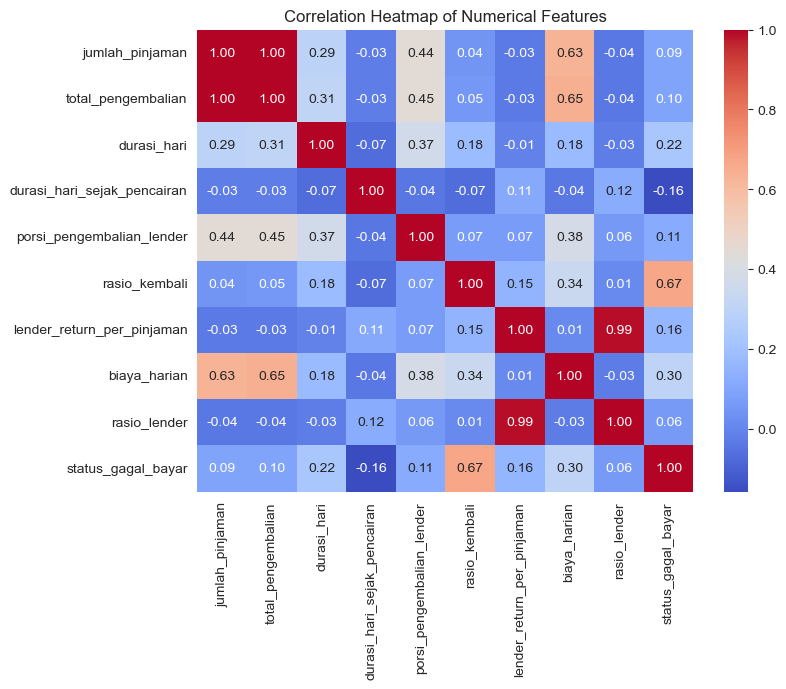

In [ ]:
# feature selection 01: numerical vs binary target -> linear relationship / pearson correlation / point-biserial
visualize_heatmap(df_train, ['jumlah_pinjaman', 'total_pengembalian', 'durasi_hari', 'durasi_hari_sejak_pencairan', 'porsi_pengembalian_lender', 'rasio_kembali', 'lender_return_per_pinjaman', 'biaya_harian', 'rasio_lender'], categorical_binary_target, 'pearson')

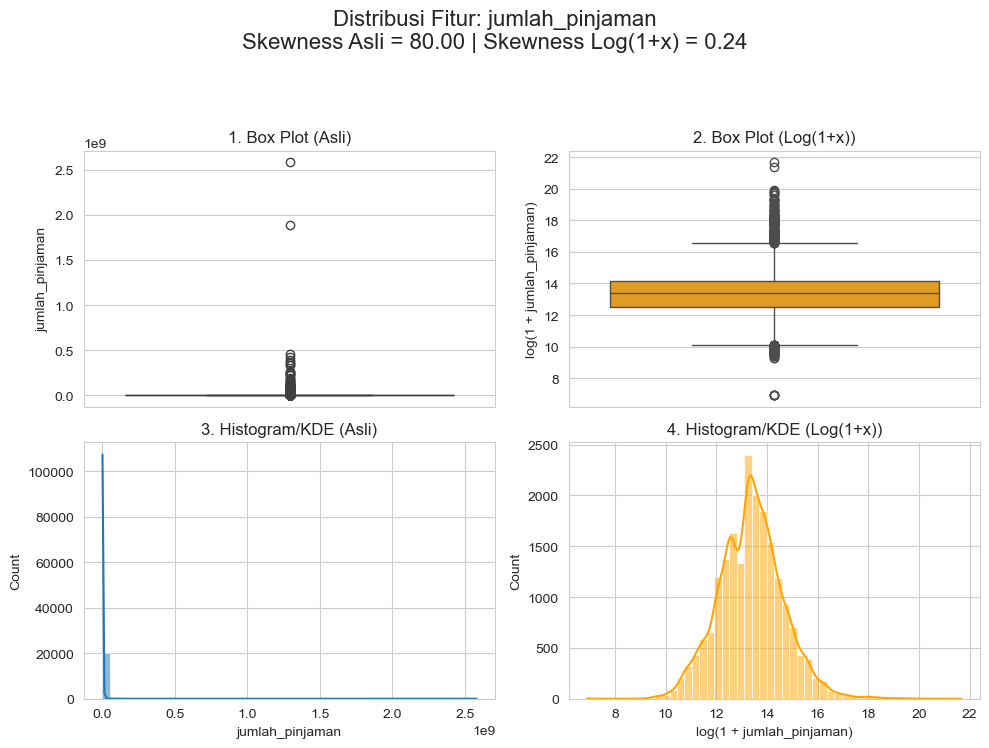

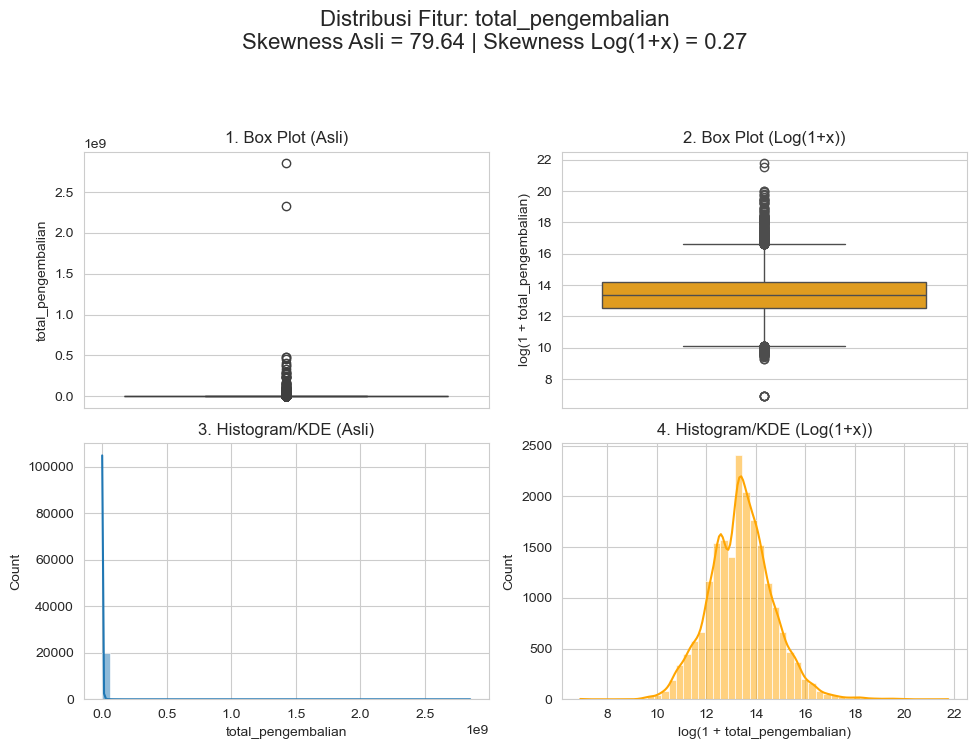

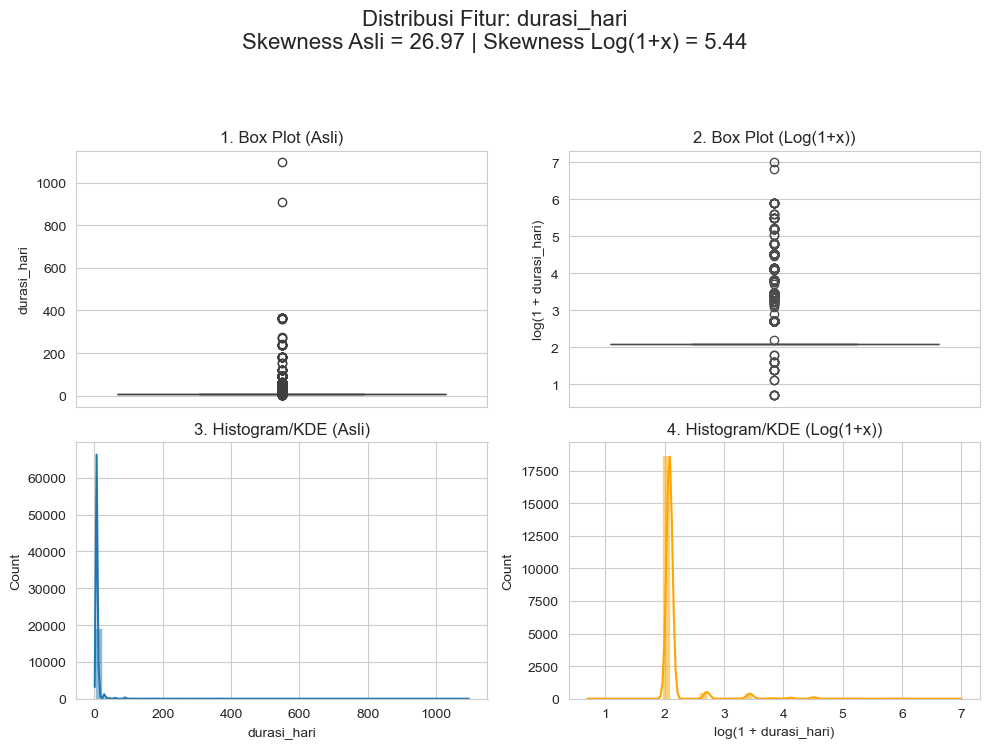

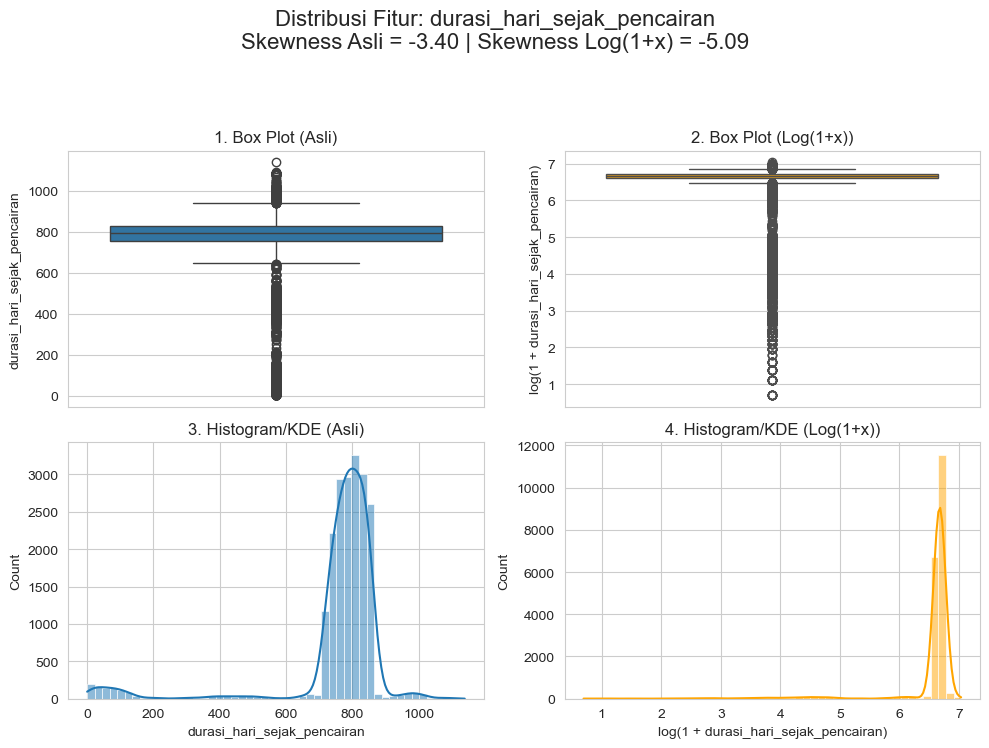

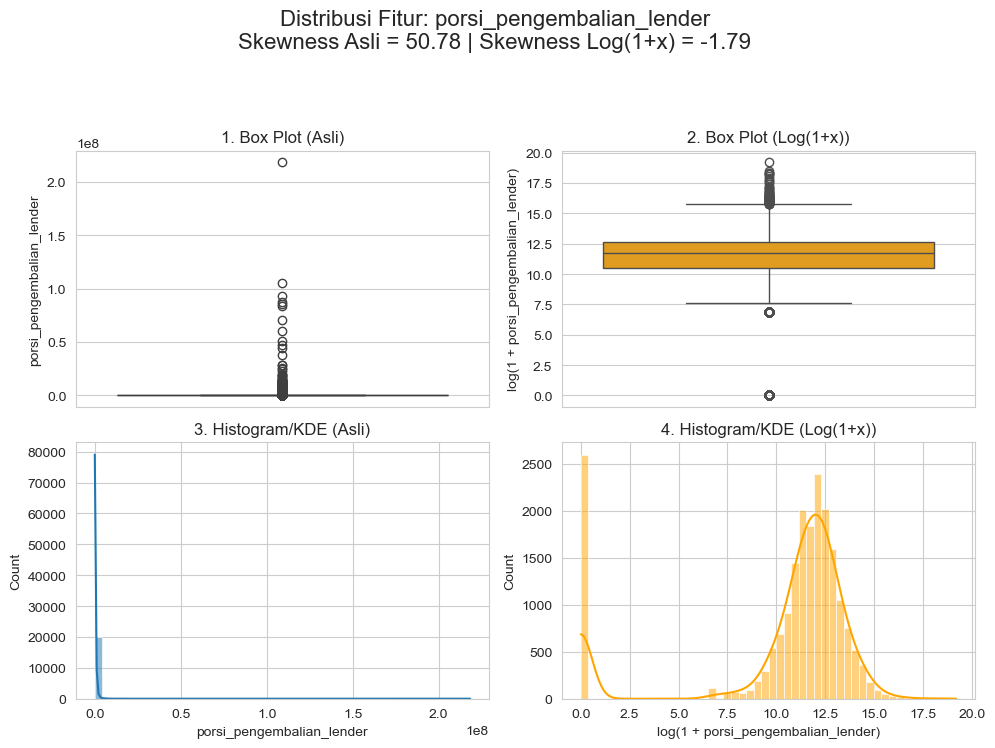

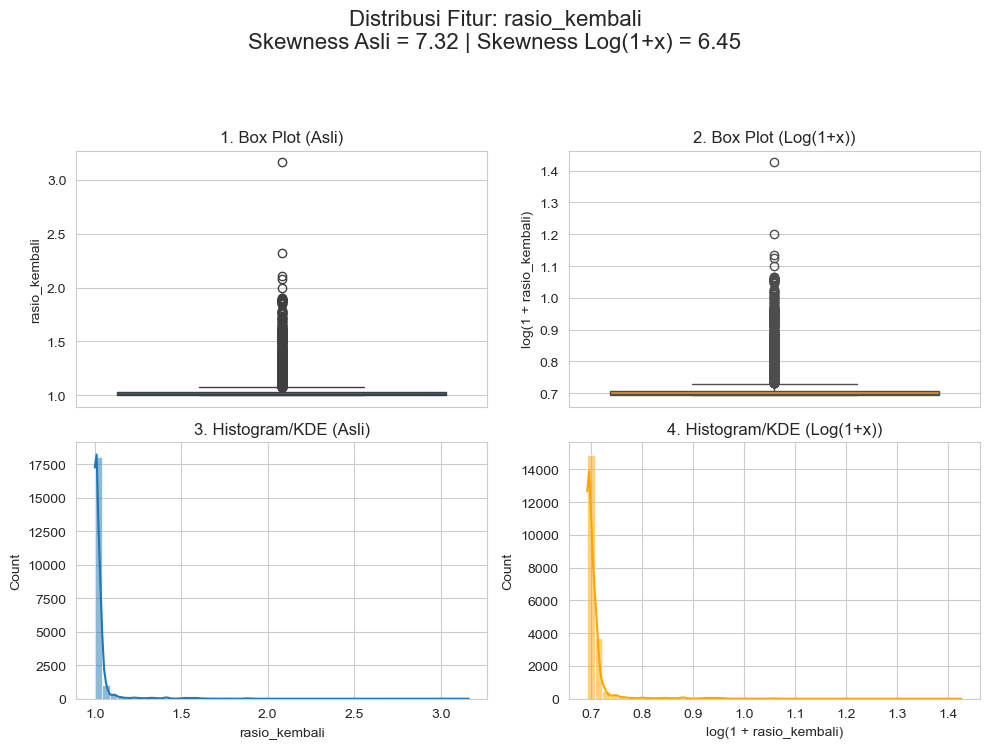

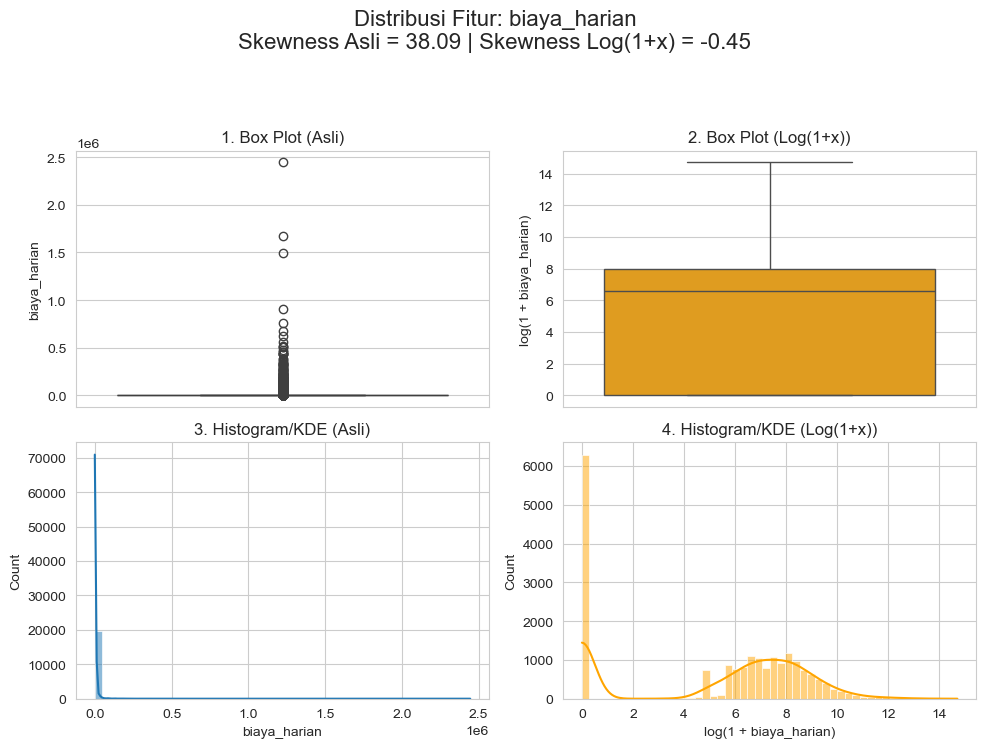

In [ ]:
visualize_numerical_distribution_with_skewness(df_train, ['jumlah_pinjaman', 'total_pengembalian', 'durasi_hari', 'durasi_hari_sejak_pencairan', 'porsi_pengembalian_lender', 'rasio_kembali', 'biaya_harian'])

In [ ]:
# menangani impact dari outliers: log transformation
numerical_to_transform = ['jumlah_pinjaman', 'total_pengembalian', 'durasi_hari', 'porsi_pengembalian_lender', 'rasio_kembali', 'biaya_harian', 'is_zero_interest']
for col in numerical_to_transform:
     df_train[col] = np.log1p(df_train[col])
     df_test[col] = np.log1p(df_test[col])

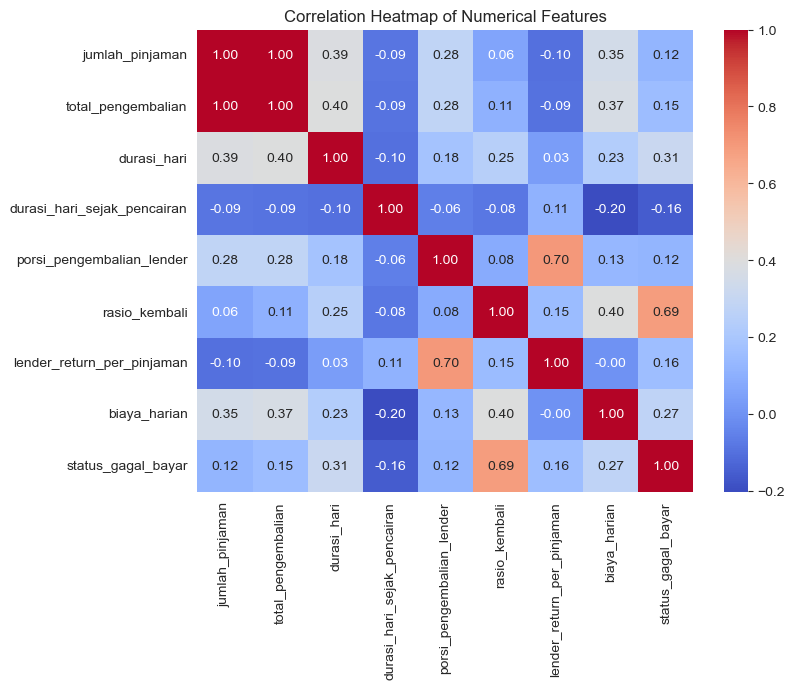

In [ ]:
visualize_heatmap(df_train, ['jumlah_pinjaman', 'total_pengembalian', 'durasi_hari', 'durasi_hari_sejak_pencairan', 'porsi_pengembalian_lender', 'rasio_kembali', 'lender_return_per_pinjaman', 'biaya_harian'], categorical_binary_target, 'pearson')

In [ ]:
# persiapkan data set yang mungkin menguntungkan untuk model berbasis non-tree/linear

# menangani outliers dengan percentile clipping
df_train_non_tree = df_train.copy()
df_test_non_tree = df_test.copy()
lower_percentile = 0.01
upper_percentile = 0.99
percentile_limits = {}
for col in numerical:
    lower = df_train_non_tree[col].quantile(lower_percentile)
    upper = df_train_non_tree[col].quantile(upper_percentile)
    percentile_limits[col] = (lower, upper)
    df_train_non_tree[col] = df_train_non_tree[col].clip(lower, upper)
    df_test_non_tree[col] = df_test_non_tree[col].clip(lower, upper)

In [ ]:
# identifikasi kelas-kelas unik pada categorical features
def print_categorical_values(column, df):
    print(f"values of '{column}':", df[column].unique())
    print("\n")
for col in categorical:
    print_categorical_values(col, df_train)

values of 'provinsi': ['Jawa Barat' 'Jawa Tengah' 'Jawa Timur' 'DKI Jakarta']


values of 'jenis_pinjaman': ['Modal_Usaha' 'Mikro_UKM' 'Multiguna' 'Investasi' 'Konsumtif']


values of 'status_peminjam': ['Peminjam_Berulang' 'Peminjam_Baru']


values of 'sektor_usaha': ['Digital' 'Kuliner' 'Perdagangan' 'Pertanian' 'Manufaktur' 'Jasa']


values of 'pendidikan': ['D3' 'S2' 'SMA' 'S1']


values of 'jenis_jaminan': ['Sertifikat' 'SK_Pegawai' 'BPKB' 'Tanpa_Jaminan']




In [ ]:
# categorical feature encoding ... (01)

# perlakukan tahun, kuartal, dan hari_dalam_minggu sebagai categorical features
def toObject(df):
    df['tahun'] = df['tahun'].astype(str)
    df['kuartal'] = df['kuartal'].astype(str)
    df['hari_dalam_minggu'] = df['hari_dalam_minggu'].astype(str)
    return df
df_train = toObject(df_train)
df_train_non_tree = toObject(df_train_non_tree)
df_test = toObject(df_test)
df_test_non_tree = toObject(df_test_non_tree)

ohe_features = ['provinsi', 'jenis_pinjaman', 'sektor_usaha', 'jenis_jaminan', 'tahun', 'kuartal', 'hari_dalam_minggu']
ode_features = ['pendidikan']
edu_order = ['SMA','D3', 'S1', 'S2']
be_features = ['status_peminjam']
binary_categories = ['Peminjam_Berulang', 'Peminjam_Baru']

In [ ]:
# categorical feature encoding ... (02)
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
def encode_categorical_features(df_train, df_test, ohe_features, ode_features, be_features, education_order, binary_categories):
    df_train = df_train.copy()
    df_test = df_test.copy()
    if ohe_features:
        ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        ohe_train = ohe.fit_transform(df_train[ohe_features])
        ohe_test = ohe.transform(df_test[ohe_features])
        ohe_columns = ohe.get_feature_names_out(ohe_features)
        df_ohe_train = pd.DataFrame(ohe_train, columns=ohe_columns, index=df_train.index)
        df_ohe_test = pd.DataFrame(ohe_test, columns=ohe_columns, index=df_test.index)
        df_train = pd.concat([df_train.drop(columns=ohe_features), df_ohe_train], axis=1)
        df_test = pd.concat([df_test.drop(columns=ohe_features), df_ohe_test], axis=1)
    if ode_features:
        for col in ode_features:
            encoder = OrdinalEncoder(categories=[education_order], dtype=int)
            df_train[col+'_encoded'] = encoder.fit_transform(df_train[[col]])
            df_test[col+'_encoded'] = encoder.transform(df_test[[col]])
            df_train.drop(columns=[col], inplace=True)
            df_test.drop(columns=[col], inplace=True)
    if be_features:
        for col in be_features:
            mapping = {binary_categories[1]: 1, binary_categories[0]: 0}
            df_train[col+'_encoded'] = df_train[col].map(mapping)
            df_test[col+'_encoded'] = df_test[col].map(mapping)
            df_train.drop(columns=[col], inplace=True)
            df_test.drop(columns=[col], inplace=True)
    return df_train, df_test

In [ ]:
# categorical feature encoding ... (02)
df_train_encoded, df_test_encoded = encode_categorical_features(df_train, df_test, ohe_features, ode_features, be_features, edu_order, binary_categories)
df_train_non_tree_encoded, df_test_non_tree_encoded = encode_categorical_features(df_train_non_tree, df_test_non_tree, ohe_features, ode_features, be_features, edu_order, binary_categories)

In [ ]:
# preview features pada train set
df_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20010 entries, 0 to 20011
Data columns (total 59 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_transaksi                     20010 non-null  int64  
 1   jumlah_pinjaman                  20010 non-null  float64
 2   total_pengembalian               20010 non-null  float64
 3   durasi_hari                      20010 non-null  float64
 4   porsi_pengembalian_lender        20010 non-null  float64
 5   status_gagal_bayar               20010 non-null  int64  
 6   is_durasi_hari_negative          20010 non-null  int64  
 7   durasi_hari_sejak_pencairan      20010 non-null  int64  
 8   is_weekend                       20010 non-null  int64  
 9   bulan_sin                        20010 non-null  float64
 10  bulan_cos                        20010 non-null  float64
 11  hari_bulan_sin                   20010 non-null  float64
 12  hari_bulan_cos         

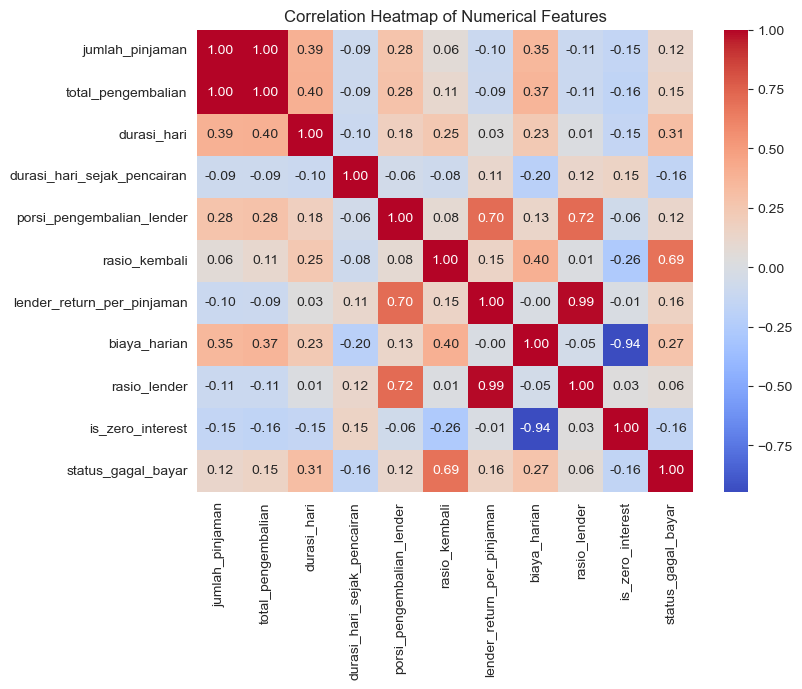

In [ ]:
# feature selection 01: numerical vs binary target -> linear relationship / pearson correlation / point-biserial
visualize_heatmap(df_train, ['jumlah_pinjaman', 'total_pengembalian', 'durasi_hari', 'durasi_hari_sejak_pencairan', 'porsi_pengembalian_lender', 'rasio_kembali', 'lender_return_per_pinjaman', 'biaya_harian', 'rasio_lender', 'is_zero_interest'], categorical_binary_target, 'pearson')

Inference:
- pertimbangkan untuk drop kolom jumlah_pinjaman dan rasio_lender jika menggunakan model berbasis linear untuk mereduksi multikolinearitas.
- jika menggunakan model berbasis pohon, abaikan saja.

In [ ]:
# mencegah multikolineritas 

# non tree (wajib) 
df_train_non_tree_encoded = df_train_non_tree_encoded.drop(columns=['jumlah_pinjaman', 'rasio_lender'], errors='ignore')
df_test_non_tree_encoded = df_test_non_tree_encoded.drop(columns=['jumlah_pinjaman', 'rasio_lender'], errors='ignore')

# tree (sunnah) 
df_train_encoded = df_train_encoded.drop(columns=['jumlah_pinjaman', 'rasio_lender'], errors='ignore')
df_test_encoded = df_test_encoded.drop(columns=['jumlah_pinjaman', 'rasio_lender'], errors='ignore')

In [ ]:
# feature selection 02: binary features vs binary target -> chi-square
from sklearn.feature_selection import chi2
# define kolom binary
chi_cols = ['is_durasi_hari_negative', 'is_weekend', 'is_total_pengembalian_illogical',
    'is_lender_return_zero', 'status_peminjam_encoded',
    'provinsi_DKI Jakarta', 'provinsi_Jawa Barat', 'provinsi_Jawa Tengah', 'provinsi_Jawa Timur',
    'jenis_pinjaman_Investasi', 'jenis_pinjaman_Konsumtif', 'jenis_pinjaman_Mikro_UKM', 
    'jenis_pinjaman_Modal_Usaha', 'jenis_pinjaman_Multiguna',
    'sektor_usaha_Digital', 'sektor_usaha_Jasa', 'sektor_usaha_Kuliner', 
    'sektor_usaha_Manufaktur', 'sektor_usaha_Perdagangan', 'sektor_usaha_Pertanian',
    'jenis_jaminan_BPKB', 'jenis_jaminan_SK_Pegawai', 'jenis_jaminan_Sertifikat',
    'jenis_jaminan_Tanpa_Jaminan',
    'tahun_2022', 'tahun_2023', 'tahun_2024', 'tahun_2025',
    'kuartal_1', 'kuartal_2', 'kuartal_3', 'kuartal_4',
    'hari_dalam_minggu_0', 'hari_dalam_minggu_1', 'hari_dalam_minggu_2',
    'hari_dalam_minggu_3', 'hari_dalam_minggu_4', 'hari_dalam_minggu_5',
    'hari_dalam_minggu_6','is_zero_interest'
]

X_chi = df_train_encoded[chi_cols]
y_chi = df_train_encoded['status_gagal_bayar']
chi_scores, p_vals = chi2(X_chi, y_chi)
chi_df = pd.DataFrame({
    'feature': chi_cols,
    'chi2_score': chi_scores,
    'p_value': p_vals
}).sort_values('p_value')

# display
chi_df

,feature,chi2_score,p_value
13,jenis_pinjaman_Multiguna,"1,095.10",0.00
28,kuartal_1,617.47,0.00
4,status_peminjam_encoded,589.79,0.00
27,tahun_2025,529.13,0.00
10,jenis_pinjaman_Konsumtif,511.71,0.00
11,jenis_pinjaman_Mikro_UKM,448.47,0.00
26,tahun_2024,387.68,0.00
29,kuartal_2,316.94,0.00
24,tahun_2022,281.47,0.00
9,jenis_pinjaman_Investasi,240.31,0.00


Inference:
- p < 0.05 → signifikan → fitur punya hubungan dengan target.
- p ≥ 0.05 → tidak signifikan → fitur kemungkinan tidak relevan.
- chi2 besar berarti feature sangat membedakan antara gagal bayar vs tidak -> feature punya informasi prediktif.
- Model non-tree based pertimbangkan untuk drop feature dengan p-value >= 0.2
- Model tree based tidak akan bermasalah sama sekali secara performa jika terdapat irrelevant feature, hanya saja kinerja komputasi akan tinggi.

In [ ]:
# # feature selection 03: ordinal feature vs binary target -> spearman_corr
# spearman_corr = df_train_encoded['pendidikan_encoded'].corr(df_train_encoded['status_gagal_bayar'], method='spearman')
# spearman_corr

In [ ]:
cols_to_drop = ['is_durasi_hari_negative', 'provinsi_Jawa Barat', 'provinsi_DKI Jakarta', 'provinsi_Jawa Timur', 'provinsi_Jawa Tengah']

df_train_encoded = df_train_encoded.drop(columns=cols_to_drop, errors='ignore')
df_test_encoded = df_test_encoded.drop(columns=cols_to_drop, errors='ignore')

df_train_non_tree_encoded = df_train_non_tree_encoded.drop(columns=cols_to_drop, errors='ignore')
df_test_non_tree_encoded = df_test_non_tree_encoded.drop(columns=cols_to_drop, errors='ignore')

In [ ]:
# feature selection 04: drop id_transaksi dari train set (irrelevant feature untuk model training)
df_train_encoded = df_train_encoded.drop(columns=['id_transaksi'], errors='ignore')
df_train_non_tree_encoded = df_train_non_tree_encoded.drop(columns=['id_transaksi'], errors='ignore')

## 4. Modeling, Evaluation, and Hyperparameter Tuning

In [ ]:
# split features and target
import math
X_train_non_tree = df_train_non_tree_encoded.drop(columns=['status_gagal_bayar'])
y_train = df_train_non_tree_encoded['status_gagal_bayar']
# store test_ids
test_ids= df_test['id_transaksi'].copy()
X_test_non_tree = df_test_non_tree_encoded.drop(columns=['id_transaksi'], errors='ignore')

X_train_tree = df_train_encoded.drop(columns=['status_gagal_bayar'])
X_test_tree = df_test_encoded.drop(columns=['id_transaksi'], errors='ignore')

# Hitung Rasio Class Weight untuk model boosting (95% : 5%)
minority_class_count = (y_train == 1).sum()
majority_class_count = (y_train == 0).sum()
scale_pos_weight_value = math.sqrt(majority_class_count/minority_class_count)

print(f"Proporsi Gagal Bayar (Kelas 1): {minority_class_count / len(y_train) * 100:.2f}%")
print(f"Nilai scale_pos_weight untuk XGBoost/LightGBM: {scale_pos_weight_value:.2f}")

Proporsi Gagal Bayar (Kelas 1): 5.03%
Nilai scale_pos_weight untuk XGBoost/LightGBM: 4.35


In [ ]:
# model selection
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score 
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb

# inisialisasi Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Logistic Regression CV
numerical_to_standardize = ['total_pengembalian', 'durasi_hari', 'porsi_pengembalian_lender', 'rasio_kembali']
passthrough_columns = [col for col in X_train_non_tree.columns.tolist() if col not in numerical_to_standardize]
lr_preprocessor = ColumnTransformer(transformers=[('num_scale', StandardScaler(), numerical_to_standardize), ('other_pass', 'passthrough', passthrough_columns)], remainder='drop')
logreg_pipeline = Pipeline([('preprocessor', lr_preprocessor), ('logreg', LogisticRegression(solver='liblinear', penalty='l1', class_weight='balanced', random_state=SEED))])
lr_scores = cross_val_score(logreg_pipeline, X_train_non_tree, y_train, cv=skf, scoring='f1_macro')
lr_mean = np.mean(lr_scores)
lr_std = np.std(lr_scores)
print(f"Logistic Regression - Macro F1 CV Score: {lr_mean:.4f} (+/- {lr_std:.4f})")

# KNN - CV
knn_preprocessor = ColumnTransformer(transformers=[('num_scale', StandardScaler(), numerical_to_standardize), ('other_pass', 'passthrough', passthrough_columns)],remainder='drop')
knn_pipe = Pipeline([('preprocessor', knn_preprocessor), ('knn', KNeighborsClassifier(n_neighbors=10, weights='distance', n_jobs=-1))])
knn_scores = cross_val_score(knn_pipe, X_train_non_tree, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)
print(f"KNN CV Macro F1: {knn_scores.mean():.4f} (+/- {knn_scores.std():.4f})")

# Decision Tree CV
dt_model = DecisionTreeClassifier(max_depth = 10, min_samples_leaf = 5, class_weight = 'balanced', random_state = SEED)
dt_scores = cross_val_score(dt_model, X_train_tree, y_train, cv=skf, scoring='f1_macro')
print(f"Decision Tree - Macro F1 CV Score: {np.mean(dt_scores):.4f} (+/- {np.std(dt_scores):.4f})")

# Random Forest CV
rf_model = RandomForestClassifier(n_estimators = 100, max_depth = 10, class_weight = 'balanced', n_jobs = -1, random_state=SEED)
rf_scores = cross_val_score(rf_model, X_train_tree, y_train, cv=skf, scoring='f1_macro')
print(f"Random Forest - Macro F1 CV Score: {np.mean(rf_scores):.4f} (+/- {np.std(rf_scores):.4f})")

# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators = 500, max_depth = 6, learning_rate = 0.1, scale_pos_weight = scale_pos_weight_value, use_label_encoder = False, eval_metric = 'logloss', random_state = SEED)
xgb_scores = cross_val_score(xgb_model, X_train_tree, y_train, cv=skf, scoring='f1_macro')
print(f"XGBoost - Macro F1 CV Score: {np.mean(xgb_scores):.4f} (+/- {np.std(xgb_scores):.4f})")

# lgbm
lgb_model = lgb.LGBMClassifier(scale_pos_weight=scale_pos_weight_value, random_state=SEED)
# lgb_model = lgb.LGBMClassifier(n_estimators = 100, max_depth = 6, learning_rate = 0.1, scale_pos_weight = scale_pos_weight_value, random_state=42)
lgb_scores = cross_val_score(lgb_model, X_train_tree, y_train, cv=skf, scoring='f1_macro')
print(f"LightGBM - Macro F1 CV Score: {np.mean(lgb_scores):.4f} (+/- {np.std(lgb_scores):.4f})")

c:\Users\tutoi\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Logistic Regression - Macro F1 CV Score: 0.7549 (+/- 0.0084)
KNN CV Macro F1: 0.7971 (+/- 0.0137)
Decision Tree - Macro F1 CV Score: 0.8808 (+/- 0.0057)
Random Forest - Macro F1 CV Score: 0.9233 (+/- 0.0102)


c:\Users\tutoi\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:10:21] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\tutoi\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:10:21] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\tutoi\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:10:22] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\tutoi\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:10:22] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\tutoi\anaconda3

XGBoost - Macro F1 CV Score: 0.9380 (+/- 0.0134)
[LightGBM] [Info] Number of positive: 805, number of negative: 15203
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001262 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1704
[LightGBM] [Info] Number of data points in the train set: 16008, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050287 -> initscore=-2.938406
[LightGBM] [Info] Start training from score -2.938406
[LightGBM] [Info] Number of positive: 805, number of negative: 15203
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000649 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1707
[LightGBM] [Info] Number of data points in the train set: 16008, n

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# define parameter
param_grid_xgb = {
    'max_depth': [5, 8, 10, 12], 
    'learning_rate': [0.01, 0.03, 0.05, 0.08], 
    'n_estimators': [600, 1000, 1500, 2000], 
    'gamma': [0.0, 0.1, 0.2, 0.3], 
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

# Model dasar (dengan bobot kelas dikunci)
xgb_base = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight_value, use_label_encoder=False, eval_metric='logloss', random_state=SEED)

# Randomized Search
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid_xgb,
    n_iter=50, # Jumlah kombinasi untuk diuji
    scoring='f1_macro',
    cv=skf,
    verbose=2,
    n_jobs=-1,
    random_state=SEED
)

random_search_xgb.fit(X_train_tree, y_train)
# Simpan Model Terbaik
xgb_tuned_clf = random_search_xgb.best_estimator_
best_xgb_score = random_search_xgb.best_score_

print(f"XGBoost TUNED Macro F1: {best_xgb_score:.4f}")
print("Best Params:", random_search_xgb.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\tutoi\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:11:48] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost TUNED Macro F1: 0.9412
Best Params: {'subsample': 0.8, 'n_estimators': 600, 'max_depth': 12, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.6}


In [ ]:
from sklearn.metrics import f1_score
def evaluate_model(model, X, y, cv, model_name=""):
    # CV score
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    # Train score 
    model.fit(X, y)
    train_pred = model.predict(X)
    train_score = f1_score(y, train_pred, average="macro")
    # Hasil evaluasi
    return {
        "model": model_name,
        "train_f1": train_score,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std()
    }

xgb_tuned_result = evaluate_model(
    model=xgb_tuned_clf, 
    X=X_train_tree, 
    y=y_train, 
    cv=skf, 
    model_name="XGBoost (Tuned)"
)
print("XGBoost Tuned Result:")
print(pd.Series(xgb_tuned_result))

c:\Users\tutoi\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:11:52] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Tuned Result:
model       XGBoost (Tuned)
train_f1               1.00
cv_mean                0.94
cv_std                 0.01
dtype: object


In [ ]:
with pd.option_context('display.float_format', '{:.7f}'.format):
    display(pd.Series(xgb_tuned_result))

model       XGBoost (Tuned)
train_f1          0.9958447
cv_mean           0.9412397
cv_std            0.0133095
dtype: object

In [ ]:
from sklearn.model_selection import cross_val_predict
xgb_oof_proba = cross_val_predict(
    xgb_tuned_clf, 
    X_train_tree, #Gunakan input data yang sesuai
    y_train, 
    cv=skf, 
    method='predict_proba', 
    n_jobs=-1
)[:, 1]

In [ ]:
# Cari Threshold Optimal (T)
thresholds = np.arange(0.05, 0.51, 0.005) 
f1_scores_at_threshold = [f1_score(y_train, (xgb_oof_proba >= t).astype(int), average='macro') for t in thresholds]

FINAL_OPTIMAL_THRESHOLD = thresholds[np.argmax(f1_scores_at_threshold)]
FINAL_OPTIMAL_MACRO_F1 = f1_scores_at_threshold[np.argmax(f1_scores_at_threshold)]

print(f"\nFINAL OPTIMAL MACRO F1 (Single XGBoost): {FINAL_OPTIMAL_MACRO_F1:.4f}")
print(f"FINAL OPTIMAL THRESHOLD (T): {FINAL_OPTIMAL_THRESHOLD:.3f}")


FINAL OPTIMAL MACRO F1 (Single XGBoost): 0.9416
FINAL OPTIMAL THRESHOLD (T): 0.505


In [ ]:
xgb_tuned_clf.fit(X_train_tree, y_train)
final_proba_submission = xgb_tuned_clf.predict_proba(X_test_tree)[:, 1]

# Terapkan Threshold Optimal
final_predictions = (final_proba_submission >= FINAL_OPTIMAL_THRESHOLD).astype(int)

c:\Users\tutoi\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:11:56] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
submission_df = pd.DataFrame({
    'id_transaksi': test_ids,
    'status_gagal_bayar': final_predictions
})
submission_df.to_csv('submission_klarifikasi.csv', index=False)

In [ ]:
# import joblib

# # Define directory
# MODEL_DIR = 'best_single_xgb_model'
# os.makedirs(MODEL_DIR, exist_ok=True)

# # Keep final XGB
# MODEL_FILE_NAME = 'xgb_model_008.pkl'
# joblib.dump(xgb_tuned_clf, os.path.join(MODEL_DIR, MODEL_FILE_NAME))

# # Keep final optimal threshold
# THRESHOLD_FILE_NAME = 'optimal_threshold_008.npy'
# np.save(os.path.join(MODEL_DIR, THRESHOLD_FILE_NAME), FINAL_OPTIMAL_THRESHOLD)

# # Skor f1 optimal
# SCORE_FILE_NAME = 'macro_f1_score_008.npy'
# np.save(os.path.join(MODEL_DIR, SCORE_FILE_NAME), FINAL_OPTIMAL_MACRO_F1)

# print(f"Model XGBoost terbaik tersimpan di: {MODEL_DIR}/{MODEL_FILE_NAME}")
# print(f"Threshold Optimal tersimpan di: {MODEL_DIR}/{THRESHOLD_FILE_NAME}")
# print(f"Skor F1 Optimal tersimpan di: {MODEL_DIR}/{SCORE_FILE_NAME}")